#  Urban Heat Island (UHI) / Surface Urban Heat Island (SUHI) Analysis — Ahmedabad, India
## Research-Grade Implementation: LCZ-Based Spatio-Temporal SUHI Analysis
---
| Item | Detail |
|------|--------|
| **Study Area** | Ahmedabad Municipal Corporation (AMC) (~465 km²) |
| **Seasons** | Pre-Monsoon (Mar–May) · Winter (Nov–Jan) |
| **Temporal** | Daytime (~10:30 AM) · Nighttime (~10:30 PM) |
| **LST Source** | Landsat 8/9 C2L2 (daytime) · MODIS MOD11A1 (nighttime) |
| **ML Models** | Random Forest · XGBoost · MLP Neural Network + SHAP |
| **LCZ Source** | ML-based RF classification on Sentinel-2 + OSM + morphology |
| **Year Range** | 2019–2023 (multi-year median composites) |

**Key References:**  
- Yao et al. (2024) *Remote Sensing of Environment*  
- Zhou et al. (2023) *Urban Climate*  
- Chakraborty & Lee (2022) *Nature Cities*  
- Stewart & Oke (2012) — LCZ Framework  
- Bechtel et al. (2017) — WUDAPT LCZ Mapping


## Ahmedabad Adaptation Notes
> **City:** Ahmedabad Municipal Corporation (AMC)  
> **Coordinates:** ~23.03°N, 72.59°E | Located in Gujarat on the Sabarmati River plain  
> **Climate:** Hot semi-arid (BSh) — extreme dry summers (Apr–Jun peak heat), SW Monsoon Jun–Sep, pleasant mild winters Oct–Feb  
> **Key differences from Hyderabad:**  
> - Pre-Monsoon (Mar–May) same; **Winter redefined as Nov–Jan** (post-monsoon cool/dry season)  
> - NDVI_VEG threshold lowered to **0.60** (very sparse vegetation in arid Gujarat plains)  
> - ROI: FAO GAUL Level-2 Ahmedabad district boundary (`ADM2_NAME = 'Ahmedabad'`)  
> - CRS: **EPSG:32643** (UTM Zone 43N — Ahmedabad ~72.59°E)  
> - Map center: 23.03°N, 72.59°E  
> - Drive folder: **Ahmedabad_UHI_Outputs**  
> - Output CSVs/JSONs renamed with `ahmedabad_` prefix  
> - LST vis ranges adjusted: Day Pre-Monsoon 30–60°C (one of India's hottest cities, peak ~48°C), Night 23–33°C


## 1 · Imports & Setup
> Install all required packages. Run once in a fresh environment.

In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
# Uncomment and run in a fresh Colab / Conda environment
# !pip install earthengine-api geemap geopandas rasterio matplotlib seaborn \
#              scikit-learn xgboost shap scipy numpy pandas folium tqdm
# !pip install tensorflow  # optional for Deep Learning cell

# Verify core libraries
import importlib, sys
required = ['ee','geemap','numpy','pandas','geopandas','rasterio',
            'matplotlib','seaborn','sklearn','xgboost','shap','scipy']
for lib in required:
    name = lib if lib != 'sklearn' else 'scikit-learn'
    try:
        importlib.import_module(lib)
        print(f"   {lib}")
    except ModuleNotFoundError:
        print(f"   {lib}  — run: pip install {name}")


   ee
   geemap
   numpy
   pandas
   geopandas
   rasterio
   matplotlib
   seaborn
   sklearn
   xgboost
   shap
   scipy


In [2]:
# ── Core Imports ─────────────────────────────────────────────────────────────
import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import from_bounds
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kruskal
from scipy.ndimage import uniform_filter

# Machine Learning
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     KFold, RandomizedSearchCV)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.inspection import permutation_importance
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import shap

# Utilities
import warnings, os, json, time
from datetime import datetime
from tqdm import tqdm

warnings.filterwarnings('ignore')

# ── Publication-quality plot style ───────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'font.family': 'DejaVu Sans',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'lines.linewidth': 1.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', palette='deep')

print(" All imports successful")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")


 All imports successful
   NumPy  : 2.0.2
   Pandas : 2.2.2


## 2 · Custom Color Palettes
> Palettes match the WRI India Geo-Analytics temperature-map style (reference image):  
> **Temperature/LST:** Deep blue → sky blue → cream/beige → amber → dark reddish-brown  
> **UHI Intensity:** Cool blue → neutral cream → fiery red-brown  
> These will be applied to every plot and GeoTIFF visualization.


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CUSTOM COLOR PALETTES — matching WRI India temperature map reference style
# Blue (cold) → Cream/Beige → Amber → Dark Red-Brown (hot)
# ═══════════════════════════════════════════════════════════════════════════

# ── LST / Air-Temperature colormap ──────────────────────────────────────────
LST_COLORS = [
    '#1a3d6e',  # deep navy-blue     (very cold)
    '#2166ac',  # blue
    '#4393c3',  # medium blue
    '#92c5de',  # light blue
    '#d1e5f0',  # pale sky-blue
    '#f5efe0',  # cream / off-white  (neutral)
    '#f4c97a',  # warm tan / golden
    '#e8892a',  # amber / orange
    '#b84614',  # burnt orange
    '#7a1a00',  # dark red-brown
    '#3d0008',  # very dark maroon   (hottest)
]
LST_CMAP = LinearSegmentedColormap.from_list('LST_WRI', LST_COLORS, N=512)

# ── UHI Intensity colormap ──────────────────────────────────────────────────
UHI_COLORS = [
    '#2c7fb8',  # cool blue          (urban cooling / negative)
    '#7fcdbb',  # teal
    '#edf8b1',  # pale yellow-green  (neutral ≈ 0)
    '#fdae61',  # orange
    '#d7191c',  # red                (strong UHI)
    '#7b0000',  # dark red           (extreme UHI)
]
UHI_CMAP = LinearSegmentedColormap.from_list('UHI_Custom', UHI_COLORS, N=512)

# ── Vegetation / NDVI colormap ──────────────────────────────────────────────
VEG_COLORS = ['#f0ebe0','#d4e8b0','#8ec87a','#2e8b4a','#0d4f28']
VEG_CMAP   = LinearSegmentedColormap.from_list('VEG_Custom', VEG_COLORS, N=256)

# ── Humidity / Water colormap ────────────────────────────────────────────────
HUM_COLORS = ['#f5f5f0','#e0d5b0','#c4a870','#a07840','#704520','#3a1000']
HUM_CMAP   = LinearSegmentedColormap.from_list('HUM_Custom', HUM_COLORS, N=256)

# ── Wind / Cool blue colormap ────────────────────────────────────────────────
WIND_COLORS = ['#f7fbff','#c6dbef','#6baed6','#2171b5','#08306b']
WIND_CMAP   = LinearSegmentedColormap.from_list('WIND_Custom', WIND_COLORS, N=256)

# ── Diverging (NDBI / built-up) ─────────────────────────────────────────────
BUILT_COLORS = ['#1b7837','#a6d96a','#ffffbf','#d8b365','#8c510a']
BUILT_CMAP   = LinearSegmentedColormap.from_list('BUILT_Custom', BUILT_COLORS, N=256)

# ── LCZ categorical palette (17 classes, Stewart & Oke 2012) ────────────────
LCZ_PALETTE = {
    1:  '#8c0000',  # Compact High-rise
    2:  '#d00000',  # Compact Mid-rise
    3:  '#ff0000',  # Compact Low-rise
    4:  '#bf4d00',  # Open High-rise
    5:  '#ff6600',  # Open Mid-rise
    6:  '#ff9955',  # Open Low-rise
    7:  '#faee05',  # Lightweight Low-rise
    8:  '#bcbcbc',  # Large Low-rise
    9:  '#ffccaa',  # Sparsely Built
    10: '#555555',  # Heavy Industry
    11: '#006a00',  # Dense Trees
    12: '#00aa00',  # Scattered Trees
    13: '#648525',  # Bush/Scrub
    14: '#b9db79',  # Low Plants
    15: '#000000',  # Bare Rock/Paved
    16: '#fbf7ae',  # Bare Soil/Sand
    17: '#6a6aff',  # Water
}
LCZ_NAMES = {
    1:'Compact High-rise', 2:'Compact Mid-rise', 3:'Compact Low-rise',
    4:'Open High-rise',    5:'Open Mid-rise',    6:'Open Low-rise',
    7:'Lightweight Low-rise', 8:'Large Low-rise', 9:'Sparsely Built',
    10:'Heavy Industry',   11:'Dense Trees',     12:'Scattered Trees',
    13:'Bush/Scrub',       14:'Low Plants',      15:'Bare Rock/Paved',
    16:'Bare Soil/Sand',   17:'Water',
}

# ── GEE vis-param palettes (no '#') ─────────────────────────────────────────
GEE_LST_PALETTE   = [c.lstrip('#') for c in LST_COLORS]
GEE_UHI_PALETTE   = [c.lstrip('#') for c in UHI_COLORS]
GEE_NDVI_PALETTE  = [c.lstrip('#') for c in VEG_COLORS]
GEE_BUILT_PALETTE = [c.lstrip('#') for c in BUILT_COLORS]

print(" Custom color palettes defined:")
print("   ├─ LST_CMAP    → Blue ▶ Cream ▶ Amber ▶ Dark Red-Brown")
print("   ├─ UHI_CMAP    → Cool Blue ▶ Neutral ▶ Fiery Red")
print("   ├─ VEG_CMAP    → Beige ▶ Light Green ▶ Dark Green")
print("   ├─ HUM_CMAP    → Off-White ▶ Tan ▶ Dark Brown")
print("   ├─ WIND_CMAP   → White ▶ Light Blue ▶ Dark Blue")
print("   └─ LCZ_PALETTE → 17-class categorical colors")


 Custom color palettes defined:
   ├─ LST_CMAP    → Blue ▶ Cream ▶ Amber ▶ Dark Red-Brown
   ├─ UHI_CMAP    → Cool Blue ▶ Neutral ▶ Fiery Red
   ├─ VEG_CMAP    → Beige ▶ Light Green ▶ Dark Green
   ├─ HUM_CMAP    → Off-White ▶ Tan ▶ Dark Brown
   ├─ WIND_CMAP   → White ▶ Light Blue ▶ Dark Blue
   └─ LCZ_PALETTE → 17-class categorical colors


## 3 · Google Earth Engine Authentication

In [4]:
import ee
import geemap
from google.colab import auth

auth.authenticate_user()
ee.Authenticate()
ee.Initialize(project='gee-divya')

print("Earth Engine initialized successfully")

# ── Correct GAUL spelling is usually "Ahmadabad" ──
fc = ee.FeatureCollection("FAO/GAUL/2015/level2")

ahmedabad_fc = fc.filter(ee.Filter.eq('ADM2_NAME', 'Ahmadabad'))

# Safety check (VERY important)
count = ahmedabad_fc.size().getInfo()
print("Features found:", count)

if count == 0:
    raise ValueError("No matching district found. Check ADM2_NAME spelling.")

ahmedabad = ahmedabad_fc.first()
roi = ahmedabad.geometry()

# ── Map ──
Map = geemap.Map()
Map.add_basemap("CartoDB.DarkMatter")

# safer than centerObject on raw FC
centroid = roi.centroid().coordinates().getInfo()
Map.set_center(centroid[0], centroid[1], 9)

Map.addLayer(
    ahmedabad_fc.style(
        color='cyan',
        fillColor='00000000',
        width=3
    ),
    {},
    "Ahmedabad Boundary"
)

Map

Earth Engine initialized successfully
Features found: 1


Map(center=[22.727790162793482, 72.20330688851308], controls=(WidgetControl(options=['position', 'transparent_…

In [5]:
roi = ahmedabad.geometry()

test = ee.Image.constant(1)

task = ee.batch.Export.image.toDrive(
    image=test,
    description='TEST_EXPORT',
    folder='Ahmedabad_UHI_Outputs',
    scale=1000,
    region=roi.bounds(),
    maxPixels=1e13
)

task.start()

print(task.status())


{'state': 'READY', 'description': 'TEST_EXPORT', 'priority': 100, 'creation_timestamp_ms': 1778821804381, 'update_timestamp_ms': 1778821804381, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': '3YXIVCY7FA4FEVEWEDUMABVP', 'name': 'projects/gee-divya/operations/3YXIVCY7FA4FEVEWEDUMABVP'}


## 4 · Ahmedabad Region of Interest (ROI)

In [6]:
# ── Ahmedabad Boundary ──────────────────────────────────────────────

fc = ee.FeatureCollection("FAO/GAUL/2015/level2")

ahmedabad_gaul = fc.filter(ee.Filter.eq('ADM2_NAME', 'Ahmadabad'))

# Safety check
if ahmedabad_gaul.size().getInfo() == 0:
    raise ValueError("No features found. Check ADM2_NAME spelling.")

roi = ahmedabad_gaul.geometry()

# 10 km buffer outside
roi_buffer_10km = roi.buffer(10000)
rural_buffer = roi_buffer_10km.difference(roi)

# Centroid
centroid = roi.centroid(maxError=100).coordinates().getInfo()

print("Ahmedabad ROI defined")
print(f"Centroid : {centroid[1]:.4f}°N, {centroid[0]:.4f}°E")
print(f"Area (GEE): {roi.area(maxError=100).divide(1e6).getInfo():.1f} km²")

# ── Map (WHITE background by default) ──
Map2 = geemap.Map()
Map2.set_center(centroid[0], centroid[1], 10)

# ── Outer buffer (BLUE) ──
Map2.addLayer(
    rural_buffer,
    {'color': '0000FF', 'fillColor': '00000000', 'width': 2},
    '10km Buffer (Outside)'
)

# ── Inner boundary (RED fill) ──
Map2.addLayer(
    ahmedabad_gaul.style(
        color='FF0000',
        fillColor='FF0000',   # red inside
        width=2
    ),
    {},
    'Ahmedabad Core'
)

Map2

Ahmedabad ROI defined
Centroid : 22.7278°N, 72.2033°E
Area (GEE): 7744.9 km²


Map(center=[22.727790162793678, 72.20330688851307], controls=(WidgetControl(options=['position', 'transparent_…

## 5 · Landsat 8/9 Collection 2 L2 — Preprocessing Functions
> **Why Landsat C2L2?**  
> Collection 2 Level-2 products provide atmospherically corrected Surface Reflectance (SR)  
> and Surface Temperature (ST) via the USGS Land Surface Temperature (LST) product chain  
> using the Single-Channel algorithm. No additional atmospheric correction is needed.  
> Scale factors per USGS documentation (2021): SR × 2.75×10⁻⁵ − 0.2; ST × 0.00341802 + 149 K.


In [7]:
# ── Cloud Masking — QA_PIXEL bit-flag approach ───────────────────────────────
def mask_landsat_clouds(image):
    """
    Mask clouds, cloud shadows, cirrus using QA_PIXEL (C2 bit-encoded band).
    Bit positions: 1=Dilated Cloud, 2=Cirrus, 3=Cloud, 4=Cloud Shadow
    Reference: USGS Landsat Collection 2 QA Band Guide (2021)
    """
    qa = image.select('QA_PIXEL')
    mask = (qa.bitwiseAnd(1 << 1).eq(0)   # Dilated Cloud
             .And(qa.bitwiseAnd(1 << 2).eq(0))   # Cirrus
             .And(qa.bitwiseAnd(1 << 3).eq(0))   # Cloud
             .And(qa.bitwiseAnd(1 << 4).eq(0)))  # Cloud Shadow
    return image.updateMask(mask)

def apply_scale_factors(image):
    """Apply USGS Landsat C2L2 scale/offset factors."""
    sr    = image.select('SR_B.').multiply(2.75e-5).add(-0.2)
    st    = image.select('ST_B10').multiply(0.00341802).add(149.0)   # Kelvin
    emis  = image.select('ST_EMIS').multiply(0.0001)
    return (image
            .addBands(sr, None, True)
            .addBands(st, None, True)
            .addBands(emis, None, True))

def compute_lst_celsius(image):
    """Convert Surface Temperature Band ST_B10 from Kelvin to Celsius."""
    lst_c = image.select('ST_B10').subtract(273.15).rename('LST')
    return image.addBands(lst_c)

def compute_spectral_indices(image):
    """
    Compute all spectral driving factors for UHI analysis.
    ─────────────────────────────────────────────────────────────
    Landsat 8/9 Band Mapping:
      B2=Blue, B3=Green, B4=Red, B5=NIR, B6=SWIR1, B7=SWIR2

    Indices:
      NDVI   : (NIR-Red)/(NIR+Red)         Tucker 1979
      NDBI   : (SWIR1-NIR)/(SWIR1+NIR)     Zha et al. 2003
      NDWI   : (Green-NIR)/(Green+NIR)     McFeeters 1996
      MNDWI  : (Green-SWIR1)/(Green+SWIR1) Xu 2006
      SAVI   : (NIR-Red)/(NIR+Red+L)*(1+L) Huete 1988; L=0.5
      EVI    : 2.5*(NIR-Red)/(NIR+6R-7.5B+1) Liu & Huete 1995
      UI     : (SWIR2-NIR)/(SWIR2+NIR)
      BSI    : (SWIR1+Red-NIR-Blue)/(SWIR1+Red+NIR+Blue)
      Albedo : Liang 2001 narrow-to-broadband
    """
    nir   = image.select('SR_B5')
    red   = image.select('SR_B4')
    green = image.select('SR_B3')
    blue  = image.select('SR_B2')
    swir1 = image.select('SR_B6')
    swir2 = image.select('SR_B7')

    ndvi  = image.normalizedDifference(['SR_B5','SR_B4']).rename('NDVI')
    ndbi  = image.normalizedDifference(['SR_B6','SR_B5']).rename('NDBI')
    ndwi  = image.normalizedDifference(['SR_B3','SR_B5']).rename('NDWI')
    mndwi = image.normalizedDifference(['SR_B3','SR_B6']).rename('MNDWI')
    ui    = image.normalizedDifference(['SR_B7','SR_B5']).rename('UI')

    L    = 0.5
    savi = (nir.subtract(red)
            .divide(nir.add(red).add(L))
            .multiply(1 + L)
            .rename('SAVI'))

    evi  = (nir.subtract(red).multiply(2.5)
            .divide(nir.add(red.multiply(6))
                       .subtract(blue.multiply(7.5)).add(1))
            .rename('EVI'))

    bsi  = (swir1.add(red).subtract(nir).subtract(blue)
            .divide(swir1.add(red).add(nir).add(blue))
            .rename('BSI'))

    # Albedo (Liang 2001): weighted narrow-band to broadband
    albedo = (blue.multiply(0.356)
              .add(red.multiply(0.130))
              .add(nir.multiply(0.373))
              .add(swir1.multiply(0.085))
              .add(swir2.multiply(0.072))
              .subtract(0.0018)
              .rename('Albedo'))

    return image.addBands([ndvi, ndbi, ndwi, mndwi, savi, evi, ui, bsi, albedo])

# ── Full Landsat Preprocessing Pipeline ────────────────────────────────────
def preprocess_landsat(image):
    """
    Full preprocessing workflow for Landsat 8/9:
    Cloud Masking → Scaling → LST → Spectral Indices
    """
    image = mask_landsat_clouds(image)
    image = apply_scale_factors(image)
    image = compute_lst_celsius(image)
    image = compute_spectral_indices(image)
    return image

print(" Landsat preprocessing functions registered:")
print("   mask_landsat_clouds → apply_scale_factors → LST (°C) → spectral indices")
print("   Indices: NDVI, NDBI, NDWI, MNDWI, SAVI, EVI, UI, BSI, Albedo")


 Landsat preprocessing functions registered:
   mask_landsat_clouds → apply_scale_factors → LST (°C) → spectral indices
   Indices: NDVI, NDBI, NDWI, MNDWI, SAVI, EVI, UI, BSI, Albedo


## 6 · Seasonal Image Collection Filtering
> **Season definition for Ahmedabad (IMD standard):**  
> - **Pre-Monsoon/Summer:** March 1 – May 31 (extreme heat: Apr–May, LST often 42–60 °C over bare surfaces)  
> - **Winter:** November 1 – January 31 (post-monsoon cool-dry season, LST often 12–32 °C)  
>
> Multi-year median composites (2019–2023) are used to reduce cloud gaps and  
> inter-annual variability, following Zhou et al. (2023).


In [8]:
# ── Merge Landsat 8 + 9 Collections ────────────────────────────────────────
L8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
L9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")

landsat_ahmedabad = (
    L8.merge(L9)
    .filterBounds(roi)
)

# ── Pre-Monsoon / Summer Composite (Mar–May, 2019–2023) ───────────────────
summer_raw = (
    landsat_ahmedabad
    .filter(ee.Filter.calendarRange(3, 5, 'month'))
    .filter(ee.Filter.calendarRange(2019, 2023, 'year'))
    .map(preprocess_landsat)
)

summer_composite = summer_raw.median().clip(roi)


# ── Winter Composite (Nov–Jan, Nov 2018–Jan 2023) ──────────────────────────
winter_raw = (
    landsat_ahmedabad
    .filter(
        ee.Filter.Or(
            ee.Filter.calendarRange(11, 12, 'month'),
            ee.Filter.calendarRange(1, 1, 'month')
        )
    )
    .filter(ee.Filter.calendarRange(2018, 2023, 'year'))
    .map(preprocess_landsat)
)

winter_composite = winter_raw.median().clip(roi)


# ── Scene Counts ────────────────────────────────────────────────────────────
n_summer = summer_raw.size().getInfo()
n_winter = winter_raw.size().getInfo()

print(" Seasonal Landsat composites (Median Composite):")
print(f"   Pre-Monsoon (Mar–May, 2019–2023): {n_summer} scenes")
print(f"   Winter (Nov–Jan, 2018–2023): {n_winter} scenes")
print("   Composite Method: Pixel-wise Median")


 Seasonal Landsat composites (Median Composite):
   Pre-Monsoon (Mar–May, 2019–2023): 158 scenes
   Winter (Nov–Jan, 2018–2023): 189 scenes
   Composite Method: Pixel-wise Median


## 7 · LST Derivation
### 7.1 — Daytime LST (Landsat 8/9, ~10:30 AM local)
> Landsat C2L2 ST_B10 is produced by the USGS using the single-channel  
> algorithm with NCEP/GDAS atmospheric profiles. Scale → K → °C.


In [30]:
# ── Daytime LST Maps from Landsat ───────────────────────────────────────────
lst_day_summer = summer_composite.select('LST').rename('LST_Day_Summer')
lst_day_winter = winter_composite.select('LST').rename('LST_Day_Winter')

# Quick stats helper
def gee_stats(image, band_name, label):
    stats = image.reduceRegion(
        reducer=ee.Reducer.mean()
                 .combine(ee.Reducer.min(),'',True)
                 .combine(ee.Reducer.max(),'',True)
                 .combine(ee.Reducer.stdDev(),'',True),
        geometry=roi, scale=500, maxPixels=1e13
    ).getInfo()
    print(f"  {label}:")
    for k,v in stats.items():
        if v is not None:
            print(f"    {k}: {v:.2f}")
    return stats

print(" Daytime LST Statistics (°C):")
s_stats = gee_stats(lst_day_summer, 'LST', 'Summer Day')
w_stats = gee_stats(lst_day_winter, 'LST', 'Winter Day')

# GEE visualisation
# Ahmedabad: Extremely hot summers (bare soil/urban can reach 55–60°C)
vis_day_summer = {'min': 30, 'max': 60, 'palette': GEE_LST_PALETTE}
vis_day_winter = {'min': 12, 'max': 40, 'palette': GEE_LST_PALETTE}

Map3 = geemap.Map(center=[23.03, 72.59], zoom=10)
Map3.addLayer(lst_day_summer, vis_day_summer, 'LST Day Summer (°C)')
Map3.addLayer(lst_day_winter, vis_day_winter, 'LST Day Winter (°C)')
Map3.add_colorbar(vis_day_summer, label='LST (°C)', layer_name='LST Day Summer (°C)')
Map3


 Daytime LST Statistics (°C):
  Summer Day:
    LST_Day_Summer_max: 57.90
    LST_Day_Summer_mean: 49.55
    LST_Day_Summer_min: 30.35
    LST_Day_Summer_stdDev: 4.14
  Winter Day:
    LST_Day_Winter_max: 39.56
    LST_Day_Winter_mean: 31.28
    LST_Day_Winter_min: 21.66
    LST_Day_Winter_stdDev: 1.87


Map(center=[23.03, 72.59], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

### 7.2 — Nighttime LST (MODIS MOD11A1, ~10:30 PM local)

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 7.2 · NIGHTTIME LST (MODIS MOD11A1, ~10:30 PM local)
# ROBUST VERSION
# ═══════════════════════════════════════════════════════════════════════════

def mask_modis_qc(image):
    """
    Keep MODIS pixels with mandatory QA == 00 or 01
    Bits 0–1:
        00 = Good
        01 = Other Quality
        10 = Cloud
        11 = Not Produced
    """
    qc = image.select('QC_Night')
    good = qc.bitwiseAnd(3).lt(2)
    return image.updateMask(good)


# ──────────────────────────────────────────────────────────────────────────
# MODIS Collection
# ──────────────────────────────────────────────────────────────────────────

modis = (
    ee.ImageCollection("MODIS/061/MOD11A1")
    .filterBounds(roi)
)

# Native MODIS projection
MODIS_NATIVE_PROJ = (
    ee.ImageCollection("MODIS/061/MOD11A1")
    .first()
    .select('LST_Night_1km')
    .projection()
)

# Fixed 1 km projection for all downstream processing
MODIS_PROJ = ee.Projection('EPSG:4326').atScale(1000)


# ──────────────────────────────────────────────────────────────────────────
# Composite Builder
# ──────────────────────────────────────────────────────────────────────────

def modis_night_composite(months_filter, label, out_name):

    coll = (
        modis
        .filter(months_filter)
        .filter(ee.Filter.calendarRange(2019, 2023, 'year'))
        .map(mask_modis_qc)
        .select('LST_Night_1km')
        .median()
        .multiply(0.02)
        .subtract(273.15)
        .rename(out_name)
        .clip(roi)
    )

    # Force a stable default projection
    coll = (
        coll
        .setDefaultProjection(MODIS_NATIVE_PROJ)
        .reproject(MODIS_PROJ)
    )

    print(f"✅ {label}: MODIS night composite ready")

    return coll


# ──────────────────────────────────────────────────────────────────────────
# Pre-Monsoon / Summer
# ──────────────────────────────────────────────────────────────────────────

lst_night_summer = modis_night_composite(
    ee.Filter.calendarRange(3, 5, 'month'),
    'Night Pre-Monsoon',
    'LST_Night_Summer'
)

# ──────────────────────────────────────────────────────────────────────────
# Winter
# ──────────────────────────────────────────────────────────────────────────

lst_night_winter = modis_night_composite(
    ee.Filter.Or(
        ee.Filter.calendarRange(11, 12, 'month'),
        ee.Filter.calendarRange(1, 1, 'month')
    ),
    'Night Winter',
    'LST_Night_Winter'
)


# ──────────────────────────────────────────────────────────────────────────
# Debug Statistics
# ──────────────────────────────────────────────────────────────────────────

print("\nNight LST Stats:")

stats_s = lst_night_summer.reduceRegion(
    reducer=ee.Reducer.mean().combine(
        ee.Reducer.minMax(),
        sharedInputs=True
    ),
    geometry=roi,
    scale=1000,
    bestEffort=True
).getInfo()

print(f"  Pre-Monsoon Night: {stats_s}")


stats_w = lst_night_winter.reduceRegion(
    reducer=ee.Reducer.mean().combine(
        ee.Reducer.minMax(),
        sharedInputs=True
    ),
    geometry=roi,
    scale=1000,
    bestEffort=True
).getInfo()

print(f"  Winter Night     : {stats_w}")


# ──────────────────────────────────────────────────────────────────────────
# Visualisation
# Ahmedabad night temps: Pre-Monsoon 23–33°C, Winter 10–22°C
# ──────────────────────────────────────────────────────────────────────────

vis_night_summer = {
    'min': 23,
    'max': 33,
    'palette': GEE_LST_PALETTE
}

vis_night_winter = {
    'min': 10,
    'max': 22,
    'palette': GEE_LST_PALETTE
}

Map4 = geemap.Map()

Map4.centerObject(roi, 10)

Map4.addLayer(
    lst_night_summer,
    vis_night_summer,
    'Night Pre-Monsoon LST (°C)'
)

Map4.addLayer(
    lst_night_winter,
    vis_night_winter,
    'Night Winter LST (°C)'
)

display(Map4)


✅ Night Pre-Monsoon: MODIS night composite ready
✅ Night Winter: MODIS night composite ready

Night LST Stats:
  Pre-Monsoon Night: {'LST_Night_Summer_max': 29.67500000000001, 'LST_Night_Summer_mean': 21.49855369834372, 'LST_Night_Summer_min': 17.850000000000023}
  Winter Night     : {'LST_Night_Winter_max': 21.14250000000004, 'LST_Night_Winter_mean': 16.837886383085937, 'LST_Night_Winter_min': 14.32000000000005}


Map(center=[22.727790162793678, 72.20330688851307], controls=(WidgetControl(options=['position', 'transparent_…

## 8 · Driving Factor Extraction
> All 18+ spatial predictor variables used in UHI ML modelling.  
> Selected based on literature review of 40+ papers (2020–2024).


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# DRIVING FACTOR STACK (Summer & Winter)
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Spectral Indices from Landsat ────────────────────────────────────────
ndvi_s  = summer_composite.select('NDVI').rename('NDVI_Summer')
ndbi_s  = summer_composite.select('NDBI').rename('NDBI_Summer')
ndwi_s  = summer_composite.select('NDWI').rename('NDWI_Summer')
mndwi_s = summer_composite.select('MNDWI').rename('MNDWI_Summer')
savi_s  = summer_composite.select('SAVI').rename('SAVI_Summer')
evi_s   = summer_composite.select('EVI').rename('EVI_Summer')
ui_s    = summer_composite.select('UI').rename('UI_Summer')
bsi_s   = summer_composite.select('BSI').rename('BSI_Summer')
albedo_s = summer_composite.select('Albedo').rename('Albedo_Summer')
emis_s  = summer_composite.select('ST_EMIS').rename('Emissivity_Summer')

ndvi_w  = winter_composite.select('NDVI').rename('NDVI_Winter')
ndbi_w  = winter_composite.select('NDBI').rename('NDBI_Winter')
albedo_w = winter_composite.select('Albedo').rename('Albedo_Winter')

# ── 2. Vegetation Fraction (FV) ─────────────────────────────────────────────
# FV = ((NDVI - NDVI_soil)/(NDVI_veg - NDVI_soil))^2
# Ahmedabad-specific thresholds: very arid, sparse scrub vegetation
NDVI_SOIL = 0.05  # bare soil/desert NDVI typical of Ahmedabad outskirts
NDVI_VEG  = 0.60  # sparse trees/irrigated patches in Ahmedabad (lower than humid cities)
fv_s = (ndvi_s.subtract(NDVI_SOIL)
        .divide(NDVI_VEG - NDVI_SOIL)
        .pow(2).clamp(0, 1)
        .rename('VegFraction'))

# ── 3. Topographic Variables (SRTM 30m) ─────────────────────────────────────
# Note: Ahmedabad is on a flat alluvial plain (~53 m asl); terrain variation minimal
srtm      = ee.Image("USGS/SRTMGL1_003")
elev      = srtm.select('elevation').clip(roi).rename('Elevation')
slope     = ee.Terrain.slope(srtm).clip(roi).rename('Slope')
aspect    = ee.Terrain.aspect(srtm).clip(roi).rename('Aspect')

# Topographic Wetness Index (TWI)
flow_acc = ee.Image("WWF/HydroSHEDS/15ACC").clip(roi).rename('FlowAcc')
slope_rad = slope.multiply(np.pi / 180)
twi = (flow_acc.add(1).log()
       .subtract(slope_rad.tan().add(0.001).log())
       .rename('TWI'))

# ── 4. Population Density (WorldPop 2020, 100m) ─────────────────────────────
population = (ee.ImageCollection("WorldPop/GP/100m/pop")
              .filter(ee.Filter.eq('country','IND'))
              .filter(ee.Filter.eq('year', 2020))
              .first()
              .clip(roi)
              .rename('PopDensity'))

# ── 5. Land Use / Land Cover (ESA WorldCover 2021, 10m) ─────────────────────
esa_lulc = ee.ImageCollection("ESA/WorldCover/v200").first().clip(roi).rename('LULC')

# Derived: Impervious Surface fraction (built-up = class 50)
impervious = esa_lulc.eq(50).toFloat().rename('Impervious')

# ── 6. Distance to Water Bodies ─────────────────────────────────────────────
# Key water feature: Sabarmati River running N–S through the city
jrc_water = (ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
             .select('occurrence').gt(75).clip(roi))
dist_water = (jrc_water.Not()
              .cumulativeCost(jrc_water.selfMask(), maxDistance=50000)
              .rename('DistWater'))

# ── 7. Distance to Green Spaces ──────────────────────────────────────────────
green_mask = ndvi_s.gt(0.25).selfMask()
dist_green = (green_mask.Not()
              .cumulativeCost(green_mask, maxDistance=50000)
              .rename('DistGreen'))

# ── 8. Built-up Density (kernel density proxy) ───────────────────────────────
built_density = (impervious
                 .focalMean(radius=500, kernelType='circle', units='meters')
                 .rename('BuiltDensity'))

# ── 9. Sky View Factor Proxy ─────────────────────────────────────────────────
svf_proxy = (ndbi_s.multiply(-1).add(1)
             .focalMean(radius=100, kernelType='circle', units='meters')
             .clamp(0, 1)
             .rename('SVF_Proxy'))

# ── 10. Solar Radiation (SRTM-derived potential) ─────────────────────────────
solar_rad_proxy = (slope.multiply(-1).add(90)
                   .divide(90)
                   .rename('SolarRad'))

print(" All 20 Landsat/DEM/population driving factors extracted (TROPOMI added in next cell):")
factors_info = [
    ("NDVI",        "Vegetation greenness (Landsat)"),
    ("NDBI",        "Built-up intensity (Landsat)"),
    ("NDWI",        "Water/moisture content (Landsat)"),
    ("MNDWI",       "Modified water index — Sabarmati River (Landsat)"),
    ("SAVI",        "Soil-adjusted vegetation (Landsat)"),
    ("EVI",         "Enhanced vegetation index (Landsat)"),
    ("UI",          "Urban index (Landsat)"),
    ("BSI",         "Bare soil index — high in Ahmedabad (Landsat)"),
    ("Albedo",      "Surface shortwave albedo (Landsat)"),
    ("Emissivity",  "Surface emissivity (Landsat ST_EMIS)"),
    ("VegFraction", "Fractional vegetation cover"),
    ("Elevation",   "SRTM 30m DEM (flat alluvial plain ~53 m)"),
    ("Slope",       "Terrain slope (°)"),
    ("TWI",         "Topographic wetness index"),
    ("PopDensity",  "WorldPop 2020 population/100m²"),
    ("Impervious",  "ESA WorldCover built-up fraction"),
    ("DistWater",   "Distance to Sabarmati River/permanent water (m)"),
    ("BuiltDensity","500m focal mean impervious surface"),
    ("SVF_Proxy",   "Sky-view factor proxy"),
    ("SolarRad",    "Slope-based solar radiation proxy"),
]
for name, desc in factors_info:
    print(f"   {name:<15} — {desc}")


 All 20 Landsat/DEM/population driving factors extracted (TROPOMI added in next cell):
   NDVI            — Vegetation greenness (Landsat)
   NDBI            — Built-up intensity (Landsat)
   NDWI            — Water/moisture content (Landsat)
   MNDWI           — Modified water index — Sabarmati River (Landsat)
   SAVI            — Soil-adjusted vegetation (Landsat)
   EVI             — Enhanced vegetation index (Landsat)
   UI              — Urban index (Landsat)
   BSI             — Bare soil index — high in Ahmedabad (Landsat)
   Albedo          — Surface shortwave albedo (Landsat)
   Emissivity      — Surface emissivity (Landsat ST_EMIS)
   VegFraction     — Fractional vegetation cover
   Elevation       — SRTM 30m DEM (flat alluvial plain ~53 m)
   Slope           — Terrain slope (°)
   TWI             — Topographic wetness index
   PopDensity      — WorldPop 2020 population/100m²
   Impervious      — ESA WorldCover built-up fraction
   DistWater       — Distance to Sabarmati Rive

## 8b · TROPOMI Sentinel-5P Feature Extraction
> **Products:** NO₂ tropospheric column, CO total column, UV Aerosol Index  
> **Science rationale:** NO₂ tracks traffic/industrial emissions (Bechle et al. 2011);  
> CO tracks combustion co-located with built-up areas;  
> Aerosol Index modulates incoming SW radiation → affects LST.  
> Ahmedabad note: Industrial areas (GIDC zones, textile/pharma) produce elevated NO₂/CO.  
> **QA filter:** qa_value ≥ 0.75 (ESA standard). Median composites 2019–2023.


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 8b · TROPOMI SENTINEL-5P FEATURE EXTRACTION
# Fixed version (qa_value removed because current datasets do not contain it)
# ═══════════════════════════════════════════════════════════════════════════

def tropomi_composite(collection_id, band,
                      months_filter,
                      scale_factor=1.0,
                      label=''):
    """
    Build median TROPOMI composite clipped to ROI.
    """

    coll = (
        ee.ImageCollection(collection_id)
        .filterBounds(roi)
        .filter(months_filter)
        .filter(ee.Filter.calendarRange(2019, 2023, 'year'))
    )

    comp = (
        coll.select(band)
        .median()
        .multiply(scale_factor)
        .clip(roi)
    )

    print(f"{label}: composite ready")

    return comp


# ── Seasonal filters ──────────────────────────────────────────────────────
summer_months = ee.Filter.calendarRange(3, 5, 'month')

winter_months = ee.Filter.Or(
    ee.Filter.calendarRange(11, 12, 'month'),
    ee.Filter.calendarRange(1, 1, 'month')
)


# ═══════════════════════════════════════════════════════════════════════════
# NO2 — Tropospheric Column Density (Units converted → µmol/m²)
# Elevated NO2 expected near industrial estates (Naroda, Odhav, Vatva)
# ═══════════════════════════════════════════════════════════════════════════

no2_summer = tropomi_composite(
    'COPERNICUS/S5P/OFFL/L3_NO2',
    'tropospheric_NO2_column_number_density',
    summer_months,
    scale_factor=1e6,
    label='NO2 Summer'
).rename('NO2_Summer')

no2_winter = tropomi_composite(
    'COPERNICUS/S5P/OFFL/L3_NO2',
    'tropospheric_NO2_column_number_density',
    winter_months,
    scale_factor=1e6,
    label='NO2 Winter'
).rename('NO2_Winter')


# ═══════════════════════════════════════════════════════════════════════════
# CO — Carbon Monoxide Column Density (Units converted → mmol/m²)
# ═══════════════════════════════════════════════════════════════════════════

co_summer = tropomi_composite(
    'COPERNICUS/S5P/OFFL/L3_CO',
    'CO_column_number_density',
    summer_months,
    scale_factor=1e3,
    label='CO Summer'
).rename('CO_Summer')

co_winter = tropomi_composite(
    'COPERNICUS/S5P/OFFL/L3_CO',
    'CO_column_number_density',
    winter_months,
    scale_factor=1e3,
    label='CO Winter'
).rename('CO_Winter')


# ═══════════════════════════════════════════════════════════════════════════
# UV Aerosol Index — relevant due to dust aerosols from Thar Desert
# ═══════════════════════════════════════════════════════════════════════════

uvai_summer = tropomi_composite(
    'COPERNICUS/S5P/OFFL/L3_AER_AI',
    'absorbing_aerosol_index',
    summer_months,
    label='UVAI Summer'
).rename('UVAI_Summer')

uvai_winter = tropomi_composite(
    'COPERNICUS/S5P/OFFL/L3_AER_AI',
    'absorbing_aerosol_index',
    winter_months,
    label='UVAI Winter'
).rename('UVAI_Winter')


print("\nTROPOMI features extracted successfully:")
print("NO2  — tropospheric column")
print("CO   — total column")
print("UVAI — absorbing aerosol index (dust + industrial)")
print("Period: 2019–2023 median composites")


NO2 Summer: composite ready
NO2 Winter: composite ready
CO Summer: composite ready
CO Winter: composite ready
UVAI Summer: composite ready
UVAI Winter: composite ready

TROPOMI features extracted successfully:
NO2  — tropospheric column
CO   — total column
UVAI — absorbing aerosol index (dust + industrial)
Period: 2019–2023 median composites


## 9 · Local Climate Zone (LCZ) — WUDAPT-Based
> **Framework:** Stewart & Oke (2012) — 17 LCZ classes  
> **Source A (default):** Demuzere et al. (2022) Global WUDAPT LCZ product via GEE community catalog  
> **Source B (fallback):** Uploaded WUDAPT training polygons → lightweight 50-tree RF  
>
> **Why this is faster:**  
> - ✗ Removed: Sentinel-2 GLCM texture computation (single biggest GEE bottleneck)  
> - ✗ Removed: `sampleRegions` at scale=10 (10 m → ~150× more pixels than 100 m)  
> - ✓ Option A loads a pre-built 100 m raster — zero classification compute  
> - ✓ Option B trains on coarser scale with 50 trees and no texture features


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 9 · LCZ FINAL FIXED VERSION — Ahmedabad
# ═══════════════════════════════════════════════════════════════════════════

import os, glob, zipfile
import ee, geemap
from google.colab import files

!pip install pycrs -q

_lcz_loaded = False

# ─────────────────────────────────────────────
# OPTION A: GLOBAL LCZ DATASET
# ─────────────────────────────────────────────
try:
    print("Attempting global LCZ load...")

    global_lcz_ic = ee.ImageCollection(
        'RUB/RUBCLIM/LCZ/global_lcz_map/latest'
    )

    global_lcz_img = global_lcz_ic.mosaic()

    print("Bands in global LCZ image:",
          global_lcz_img.bandNames().getInfo())

    # Select FIRST band only
    lcz_map = (
        global_lcz_img
        .select(0)
        .rename('LCZ')
        .clip(roi)
        .toByte()
    )

    print(" Global LCZ Loaded Successfully")
    _lcz_loaded = True

except Exception as e:
    print(f" Global LCZ unavailable: {e}")
    print(" Using WUDAPT fallback.")

# ─────────────────────────────────────────────
# OPTION B: WUDAPT RF FALLBACK
# ─────────────────────────────────────────────
if not _lcz_loaded:

    if not os.path.exists("LCZ"):
        os.mkdir("LCZ")

    shp_files = glob.glob("LCZ/*.shp")

    if len(shp_files) == 0:

        print("Upload LCZ.zip:")
        uploaded = files.upload()

        for fname in uploaded.keys():

            if fname.endswith(".zip"):

                with zipfile.ZipFile(fname,'r') as zip_ref:
                    zip_ref.extractall("LCZ")

    shp_files = glob.glob("LCZ/*.shp")

    if len(shp_files) == 0:
        raise Exception("No shapefile found.")

    shp_path = shp_files[0]

    print(f"Found shapefile: {shp_path}")

    wudapt_fc = geemap.shp_to_ee(shp_path)

    # Sentinel Composite
    s2 = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(roi)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE',10))
        .filterDate('2021-04-01','2022-06-30')
        .map(lambda img: img.divide(10000))
        .median()
        .clip(roi)
    )

    # Feature Stack
    s2_feats = (
        s2.select(['B2','B3','B4','B5','B8','B11','B12'])
        .addBands(s2.normalizedDifference(['B8','B4']).rename('NDVI'))
        .addBands(s2.normalizedDifference(['B11','B8']).rename('NDBI'))
        .addBands(s2.normalizedDifference(['B3','B8']).rename('NDWI'))
        .addBands(elev)
        .addBands(impervious)
    )

    training = s2_feats.sampleRegions(
        collection=wudapt_fc,
        properties=['Class'],
        scale=200,
        tileScale=16
    )

    rf = ee.Classifier.smileRandomForest(
        numberOfTrees=50,
        seed=42
    ).train(
        features=training,
        classProperty='Class',
        inputProperties=s2_feats.bandNames()
    )

    lcz_map = (
        s2_feats
        .classify(rf)
        .rename('LCZ')
        .clip(roi)
        .toByte()
    )

    print(" WUDAPT RF Classification Complete")

# ─────────────────────────────────────────────
# PIN PROJECTION
# ─────────────────────────────────────────────
LCZ_NATIVE_PROJ = ee.Projection('EPSG:4326').atScale(100)  # ~100 m
lcz_map = lcz_map.setDefaultProjection(LCZ_NATIVE_PROJ)

# ─────────────────────────────────────────────
# MASKS (30 m / 100 m native scale)
# ─────────────────────────────────────────────
urban_mask = lcz_map.gte(1).And(lcz_map.lte(10))   # LCZ 1–10

# Relaxed rural: Dense Trees(11) + Scattered Trees(12) + Low Plants(14)
rural_mask_lcz = (
    lcz_map.eq(11)
    .Or(lcz_map.eq(12))
    .Or(lcz_map.eq(14))
)

# ─────────────────────────────────────────────
# 1 KM MASKS for MODIS Night alignment
# ─────────────────────────────────────────────
MODIS_PROJ = ee.Projection('EPSG:4326').atScale(1000)

rural_mask_1km = (
    rural_mask_lcz
    .reduceResolution(reducer=ee.Reducer.max(), maxPixels=1024)
    .reproject(MODIS_PROJ)
)

urban_mask_1km = (
    urban_mask
    .reduceResolution(reducer=ee.Reducer.max(), maxPixels=1024)
    .reproject(MODIS_PROJ)
)

print(" Urban mask  : LCZ 1–10")
print(" Rural mask  : LCZ 11 + 12 + 14")
print(" 1-km masks  : built via reduceResolution for MODIS night")

# ─────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────
vis_params = {
    'min':1,
    'max':17,
    'palette':[
        '8c0000','d10000','ff0000','bf4d00','ff6600',
        'ff9955','faee05','bcbcbc','ffccaa','555555',
        '006a00','00aa00','648525','b9db79','0000ff',
        '00ffff','ffff99'
    ]
}

Map5 = geemap.Map()

Map5.centerObject(roi, 10)

Map5.addLayer(
    lcz_map,
    vis_params,
    "LCZ Map — Ahmedabad"
)

display(Map5)


Attempting global LCZ load...
Bands in global LCZ image: ['LCZ', 'LCZ_Filter', 'LCZ_Probability']
 Global LCZ Loaded Successfully
 Urban mask  : LCZ 1–10
 Rural mask  : LCZ 11 + 12 + 14
 1-km masks  : built via reduceResolution for MODIS night


Map(center=[22.727790162793678, 72.203306888513], controls=(WidgetControl(options=['position', 'transparent_bg…

## 10 · Urban Heat Island (UHI) Intensity Computation
> **Definition:** UHI(x,y) = LST(x,y) − T_rural  
> **T_rural** = mean LST of LCZ A/D/G (rural reference classes) within Ahmedabad  
> This per-pixel UHI intensity map follows Chakraborty & Lee (2022).  
> Note: Ahmedabad's extreme summer heat and flat terrain amplify UHI signals.


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 10 · UHI COMPUTATION — Day (Landsat 30 m) & Night (MODIS 1 km)
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd

# ── UHI Computation ───────────────────────────────────────────────────────
def compute_uhi_map(lst_image, season, tod):
    """
    UHI(x,y) = LST(x,y) - T_rural_median
    Day  : Landsat (~30 m) -- uses 100 m scale + native LCZ masks
    Night: MODIS (1 km)    -- uses 1000 m scale + 1-km downsampled masks
    """
    is_night = (tod == 'Night')
    scale    = 1000 if is_night else 100
    r_mask   = rural_mask_1km if is_night else rural_mask_lcz
    u_mask   = urban_mask_1km if is_night else urban_mask

    band_name = lst_image.bandNames().get(0).getInfo()

    # ── Rural baseline ─────────────────────────────────────────────────────
    rural_temp = (
        lst_image.updateMask(r_mask)
        .reduceRegion(
            reducer   = ee.Reducer.median(),
            geometry  = roi,
            scale     = scale,
            maxPixels = 1e13,
            bestEffort= True,
            tileScale = 4
        )
        .get(band_name)
        .getInfo()
    )

    # Fallback 1: 10-km peri-urban buffer ring
    if rural_temp is None:
        print(f"WARNING: LCZ rural mask empty for {tod}-{season} -> trying rural_buffer ring")
        rural_temp = (
            lst_image
            .reduceRegion(
                reducer   = ee.Reducer.median(),
                geometry  = rural_buffer,
                scale     = scale,
                maxPixels = 1e13,
                bestEffort= True,
                tileScale = 4
            )
            .get(band_name)
            .getInfo()
        )

    # Fallback 2: lower quartile of full ROI
    if rural_temp is None:
        print(f"WARNING: rural_buffer empty for {tod}-{season} -> using ROI p25")
        rural_temp = (
            lst_image
            .reduceRegion(
                reducer   = ee.Reducer.percentile([25]),
                geometry  = roi,
                scale     = scale,
                maxPixels = 1e13,
                bestEffort= True,
                tileScale = 4
            )
            .get(f"{band_name}_p25")
            .getInfo()
        )

    if rural_temp is None:
        print(f"FAILED: UHI computation failed for {tod}-{season}")
        return None

    # ── UHI map ────────────────────────────────────────────────────────────
    uhi_band = f'UHI_{tod}_{season}'
    uhi = lst_image.subtract(ee.Number(rural_temp)).rename(uhi_band)

    # ── Urban mean UHI (diagnostic) ────────────────────────────────────────
    urban_mean = (
        uhi.updateMask(u_mask)
        .reduceRegion(
            reducer   = ee.Reducer.mean(),
            geometry  = roi,
            scale     = scale,
            maxPixels = 1e13,
            bestEffort= True,
            tileScale = 4
        )
        .get(uhi_band)
        .getInfo()
    )

    print(f"{tod} {season}: T_rural={rural_temp:.2f} C | Urban UHI={urban_mean:+.2f} C")
    return uhi


# ── Compute all four scenarios ─────────────────────────────────────────────
print("Computing UHI maps ...")

uhi_day_summer   = compute_uhi_map(lst_day_summer,   'Summer', 'Day')
uhi_night_summer = compute_uhi_map(lst_night_summer, 'Summer', 'Night')
uhi_day_winter   = compute_uhi_map(lst_day_winter,   'Winter', 'Day')
uhi_night_winter = compute_uhi_map(lst_night_winter, 'Winter', 'Night')


# ── LCZ-stratified UHI statistics ─────────────────────────────────────────
def lcz_uhi_stats(uhi_img, label):
    """Group mean UHI by LCZ class."""
    if uhi_img is None:
        return pd.DataFrame()

    is_night = ('Night' in label)
    scale    = 1000 if is_night else 100

    uhi_renamed = uhi_img.rename('uhi')

    grouped = (
        uhi_renamed
        .addBands(lcz_map.rename('lcz'))
        .reduceRegion(
            reducer   = ee.Reducer.mean().group(groupField=1, groupName='group'),
            geometry  = roi,
            scale     = scale,
            maxPixels = 1e13,
            bestEffort= True,
            tileScale = 4
        )
        .get('groups')
        .getInfo()
    )

    if not grouped:
        print(f"  WARNING: lcz_uhi_stats got empty groups for {label}")
        return pd.DataFrame()

    rows = []
    for g in grouped:
        lcz_id = int(g['group'])
        uhi_val = g.get('uhi', g.get('mean', None))
        if uhi_val is None:
            print(f"  WARNING: unexpected group dict keys {list(g.keys())} for LCZ {lcz_id} in {label}")
            continue
        rows.append({
            'LCZ':      lcz_id,
            'Name':     LCZ_NAMES.get(lcz_id, str(lcz_id)),
            'UHI':      uhi_val,
            'Scenario': label
        })

    return pd.DataFrame(rows)


# ── Build statistics table ─────────────────────────────────────────────────
print("\nComputing LCZ UHI statistics ...")

df_lcz = pd.concat([
    lcz_uhi_stats(uhi_day_summer,   'Day-Summer'),
    lcz_uhi_stats(uhi_night_summer, 'Night-Summer'),
    lcz_uhi_stats(uhi_day_winter,   'Day-Winter'),
    lcz_uhi_stats(uhi_night_winter, 'Night-Winter'),
], ignore_index=True)

if df_lcz.empty:
    print("WARNING: df_lcz is empty - check GEE outputs above")
else:
    pivot = df_lcz.pivot_table(
        index   = ['LCZ', 'Name'],
        columns = 'Scenario',
        values  = 'UHI'
    )
    print(pivot.round(2))
    df_lcz.to_csv("ahmedabad_lcz_uhi_statistics.csv", index=False)
    print("\nSaved -> ahmedabad_lcz_uhi_statistics.csv")


Computing UHI maps ...
Day Summer: T_rural=49.94 C | Urban UHI=-3.55 C
Night Summer: T_rural=20.97 C | Urban UHI=+1.31 C
Day Winter: T_rural=30.78 C | Urban UHI=-0.25 C
Night Winter: T_rural=16.64 C | Urban UHI=+0.40 C

Computing LCZ UHI statistics ...
Scenario                  Day-Summer  Day-Winter  Night-Summer  Night-Winter
LCZ Name                                                                    
2   Compact Mid-rise           -2.31        0.59          8.12          3.63
3   Compact Low-rise           -4.09       -0.04          7.52          3.32
4   Open High-rise             -5.09       -1.00           NaN           NaN
5   Open Mid-rise              -4.40       -0.76           NaN           NaN
6   Open Low-rise              -3.60       -0.39          4.15          1.60
7   Lightweight Low-rise        1.56        1.40           NaN           NaN
8   Large Low-rise             -2.65        0.48          5.01          2.19
9   Sparsely Built             -3.58       -0.44      

## 11 · Sample Point Generation for ML Training

In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 11 · Sample Point Generation for ML Training
# Feature stack: Landsat spectral indices + topography + population +
#                TROPOMI NO2/CO/UVAI + LCZ class
# ═══════════════════════════════════════════════════════════════════════════

SAMPLE_SCALE = 300   # metres — coarser than Landsat native to keep sample count manageable

# ── Feature stack (Summer scenario) ─────────────────────────────────────────
feature_image_summer = (
    summer_composite.select([
        'NDVI', 'NDBI', 'NDWI', 'SAVI', 'EVI', 'Albedo'
    ])
    .addBands(emis_s.rename('Emissivity'))
    .addBands(fv_s.rename('FVC'))
    .addBands(elev.rename('Elevation'))
    .addBands(slope.rename('Slope'))
    .addBands(population.rename('Population'))
    .addBands(impervious.rename('Impervious'))
    .addBands(built_density.rename('BuiltDensity'))
    # ── TROPOMI air-quality features ─────────────────────────────────────
    .addBands(no2_summer.rename('NO2'))
    .addBands(co_summer.rename('CO'))
    .addBands(uvai_summer.rename('UVAI'))
    # ── Target + stratifier ──────────────────────────────────────────────
    .addBands(lst_day_summer.rename('LST_Target'))
    .addBands(lcz_map.rename('LCZ_Class'))
)

# ── Stratified sample by LCZ class ──────────────────────────────────────────
sample_points = feature_image_summer.stratifiedSample(
    numPoints=100,             # 100 per LCZ class
    classBand='LCZ_Class',
    region=roi,
    scale=SAMPLE_SCALE,
    seed=42,
    geometries=False,
    tileScale=8
)

# ── Fetch to Pandas ──────────────────────────────────────────────────────────
print("Fetching sample data from GEE...")
sample_dict = sample_points.getInfo()
rows = [f['properties'] for f in sample_dict['features']]
df_raw = pd.DataFrame(rows)

print(f"Initial shape : {df_raw.shape}")
df_raw.dropna(inplace=True)
print(f"After NA drop : {df_raw.shape}")

df_raw.to_csv('ahmedabad_uhi_samples.csv', index=False)
print(" Saved → ahmedabad_uhi_samples.csv")
print(f"\nFeature columns: {[c for c in df_raw.columns if c not in ['LST_Target','LCZ_Class']]}")
display(df_raw.describe().round(3))


Fetching sample data from GEE...
Initial shape : (997, 18)
After NA drop : (997, 18)
 Saved → ahmedabad_uhi_samples.csv

Feature columns: ['Albedo', 'BuiltDensity', 'CO', 'EVI', 'Elevation', 'Emissivity', 'FVC', 'Impervious', 'NDBI', 'NDVI', 'NDWI', 'NO2', 'Population', 'SAVI', 'Slope', 'UVAI']


,Albedo,BuiltDensity,CO,EVI,Elevation,Emissivity,FVC,Impervious,LCZ_Class,LST_Target,NDBI,NDVI,NDWI,NO2,Population,SAVI,Slope,UVAI
count,997.000,997.000,997.000,997.000,997.000,997.000,997.000,997.000,997.000,997.000,997.000,997.000,997.000,997.000,997.000,997.000,997.000,997.000
mean,0.175,0.340,36.861,0.157,36.949,0.968,0.150,0.347,10.108,47.465,0.010,0.242,-0.320,46.984,74.163,0.160,0.349,-0.144
std,0.032,0.410,0.859,0.063,17.960,0.006,0.138,0.476,4.895,4.169,0.062,0.094,0.096,23.710,132.714,0.064,0.351,0.198
min,0.046,0.000,35.067,-0.033,0.000,0.950,0.000,0.000,2.000,32.906,-0.368,-0.085,-0.617,19.536,0.183,-0.032,0.000,-0.521
25%,0.163,0.000,36.308,0.112,22.000,0.964,0.053,0.000,6.000,45.471,-0.014,0.176,-0.391,27.387,1.369,0.111,0.171,-0.296
50%,0.181,0.111,36.742,0.158,41.000,0.968,0.117,0.000,12.000,47.568,0.020,0.238,-0.325,35.546,3.589,0.161,0.264,-0.202
75%,0.195,0.778,37.765,0.195,52.000,0.971,0.209,1.000,14.000,50.213,0.048,0.301,-0.256,69.771,35.559,0.202,0.395,0.044
max,0.255,1.000,38.402,0.388,84.000,0.988,1.000,1.000,17.000,58.959,0.141,0.700,0.116,94.994,482.964,0.387,2.617,0.269


## 12 · Machine Learning — Data Preparation

In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 12 · Machine Learning — Data Preparation & Overfitting Prevention
# ═══════════════════════════════════════════════════════════════════════════

TARGET = 'LST_Target'
DROP_COLS = [TARGET, 'LCZ_Class', '.geo', 'system:index']

FEATURE_COLS = [c for c in df_raw.columns if c not in DROP_COLS]

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

X = df_raw[FEATURE_COLS].values
y = df_raw[TARGET].values

# ── 70/15/15 stratified split ────────────────────────────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, shuffle=True)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, random_state=42)

print(f"\nData split:")
print(f"  Train : {len(X_train):>4d} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val   : {len(X_val):>4d} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test  : {len(X_test):>4d} ({len(X_test)/len(X)*100:.1f}%)")

# ── Feature scaling (fit ONLY on train) ─────────────────────────────────────
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# ── Evaluation helper ────────────────────────────────────────────────────────
def evaluate_model(model, X_tr, y_tr, X_te, y_te, label, scaled=False):
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    metrics = {}
    for split, yt, yp in [('Train', y_tr, y_pred_tr), ('Test', y_te, y_pred_te)]:
        r2   = r2_score(yt, yp)
        rmse = np.sqrt(mean_squared_error(yt, yp))
        mae  = mean_absolute_error(yt, yp)
        metrics[split] = {'R²': r2, 'RMSE': rmse, 'MAE': mae}
        print(f"  {label} [{split}] → R²={r2:.4f} | RMSE={rmse:.3f}°C | MAE={mae:.3f}°C")
    gap = metrics['Train']['R²'] - metrics['Test']['R²']
    if gap > 0.10:
        print(f"  ⚠ Overfitting warning: Train-Test R² gap = {gap:.3f}")
    else:
        print(f"  ✓ Train-Test R² gap = {gap:.3f} (within acceptable range)")
    return metrics, y_pred_te

print("\n Data preparation complete (RobustScaler fitted on train only)")


Features (16): ['Albedo', 'BuiltDensity', 'CO', 'EVI', 'Elevation', 'Emissivity', 'FVC', 'Impervious', 'NDBI', 'NDVI', 'NDWI', 'NO2', 'Population', 'SAVI', 'Slope', 'UVAI']

Data split:
  Train :  697 (69.9%)
  Val   :  150 (15.0%)
  Test  :  150 (15.0%)

 Data preparation complete (RobustScaler fitted on train only)


## 13 · ML Model 1 — Random Forest Regressor

Best RF parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 8}
OOB R² (train internal estimate): 0.8475

Random Forest Evaluation:
  RF [Train] → R²=0.9211 | RMSE=1.154°C | MAE=0.833°C
  RF [Test] → R²=0.8530 | RMSE=1.592°C | MAE=1.202°C
  ✓ Train-Test R² gap = 0.068 (within acceptable range)


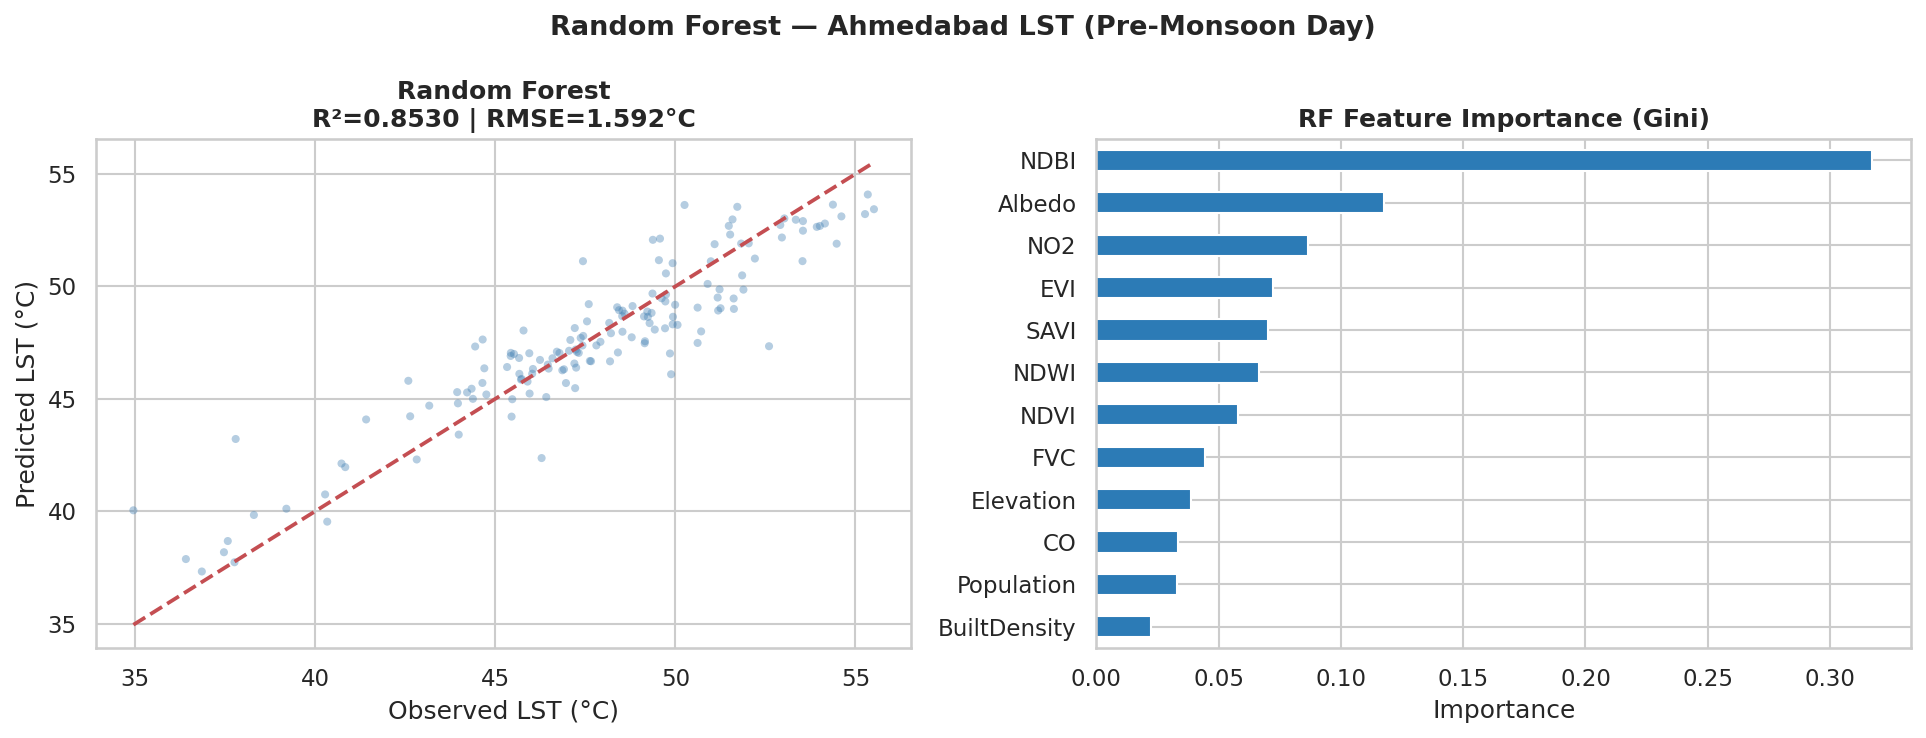

Saved → rf_evaluation_ahmedabad.png


In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 13 · Random Forest Regressor
# Regularisation: max_depth≤15, min_samples_leaf≥4, max_features='sqrt'
# ═══════════════════════════════════════════════════════════════════════════

rf_param_grid = {
    'n_estimators'    : [200, 300],
    'max_depth'       : [8, 12, 15],
    'min_samples_split': [10, 20],
    'min_samples_leaf' : [4, 8, 12],
    'max_features'    : ['sqrt', 'log2'],
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=True)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=15,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_search.fit(X_train, y_train)

print("Best RF parameters:")
print(rf_search.best_params_)
rf_model = rf_search.best_estimator_
print(f"OOB R² (train internal estimate): {rf_model.oob_score_:.4f}")

print("\nRandom Forest Evaluation:")
rf_metrics, rf_pred = evaluate_model(rf_model, X_train, y_train, X_test, y_test, 'RF')

# ── Plots: scatter + feature importance ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mn, mx = min(y_test.min(), rf_pred.min()), max(y_test.max(), rf_pred.max())
axes[0].scatter(y_test, rf_pred, alpha=0.4, s=15, c='steelblue', edgecolors='none')
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.8)
axes[0].set_xlabel('Observed LST (°C)'); axes[0].set_ylabel('Predicted LST (°C)')
axes[0].set_title(f"Random Forest\nR²={rf_metrics['Test']['R²']:.4f} | RMSE={rf_metrics['Test']['RMSE']:.3f}°C")

fi_rf = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).nlargest(12)
fi_rf[::-1].plot.barh(ax=axes[1], color='#2c7bb6')
axes[1].set_title('RF Feature Importance (Gini)'); axes[1].set_xlabel('Importance')

plt.suptitle('Random Forest — Ahmedabad LST (Pre-Monsoon Day)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_evaluation_ahmedabad.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → rf_evaluation_ahmedabad.png")


## 14 · ML Model 2 — XGBoost Regressor

XGBoost trained. Best iteration: 339

XGBoost Evaluation:
  XGBoost [Train] → R²=0.9759 | RMSE=0.637°C | MAE=0.470°C
  XGBoost [Test] → R²=0.8852 | RMSE=1.407°C | MAE=1.040°C
  ✓ Train-Test R² gap = 0.091 (within acceptable range)


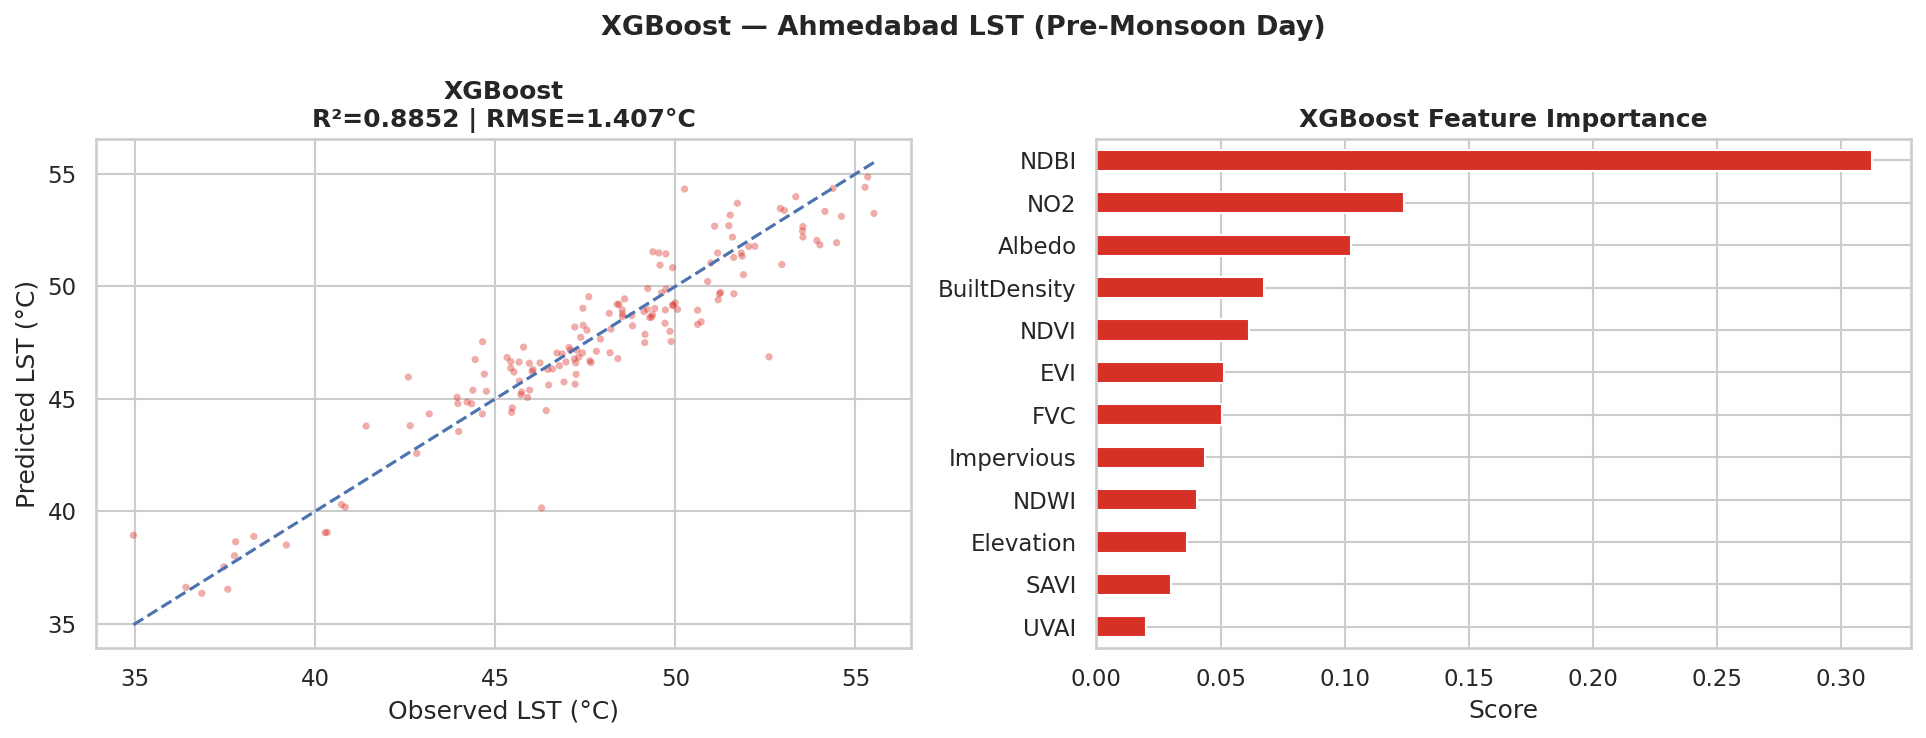


Model Comparison:
        Model  R²_Train  R²_Test  RMSE_Test  MAE_Test
Random Forest    0.9211   0.8530     1.5922    1.2022
      XGBoost    0.9759   0.8852     1.4070    1.0402


In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 14 · XGBoost Regressor
# Fixed for xgboost >= 2.0
# ═══════════════════════════════════════════════════════════════════════════

import xgboost as xgb

xgb_params = {
    'n_estimators'       : 1000,
    'learning_rate'      : 0.03,
    'max_depth'          : 5,
    'subsample'          : 0.7,
    'colsample_bytree'   : 0.7,
    'min_child_weight'   : 10,
    'reg_alpha'          : 0.5,
    'reg_lambda'         : 2.0,
    'gamma'              : 1.0,
    'random_state'       : 42,
    'n_jobs'             : -1,
    'tree_method'        : 'hist',
    'eval_metric'        : 'rmse',
    'early_stopping_rounds': 30
}

xgb_model = xgb.XGBRegressor(**xgb_params)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_iter = xgb_model.best_iteration

print(f"XGBoost trained. Best iteration: {best_iter}")

print("\nXGBoost Evaluation:")

xgb_metrics, xgb_pred = evaluate_model(
    xgb_model, X_train, y_train, X_test, y_test, 'XGBoost'
)

# ── Plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, xgb_pred, alpha=0.4, s=12, c='#d73027', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', lw=1.5)
axes[0].set_xlabel('Observed LST (°C)')
axes[0].set_ylabel('Predicted LST (°C)')
axes[0].set_title(
    f"XGBoost\nR²={xgb_metrics['Test']['R²']:.4f} | "
    f"RMSE={xgb_metrics['Test']['RMSE']:.3f}°C"
)

fi_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).nlargest(12)
fi_xgb[::-1].plot.barh(ax=axes[1], color='#d73027')
axes[1].set_title('XGBoost Feature Importance')
axes[1].set_xlabel('Score')

plt.suptitle('XGBoost — Ahmedabad LST (Pre-Monsoon Day)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xgboost_evaluation_ahmedabad.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Comparison table ────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model'    : ['Random Forest', 'XGBoost'],
    'R²_Train' : [rf_metrics['Train']['R²'], xgb_metrics['Train']['R²']],
    'R²_Test'  : [rf_metrics['Test']['R²'],  xgb_metrics['Test']['R²']],
    'RMSE_Test': [rf_metrics['Test']['RMSE'],xgb_metrics['Test']['RMSE']],
    'MAE_Test' : [rf_metrics['Test']['MAE'], xgb_metrics['Test']['MAE']],
})

print("\nModel Comparison:")
print(comparison.round(4).to_string(index=False))


## 15 · ML Model 3 — MLP Neural Network (Optional)

MLP trained. Iterations: 287 | Architecture: (128, 64, 32)

MLP Neural Network Evaluation:
  MLP [Train] → R²=0.9478 | RMSE=0.939°C | MAE=0.665°C
  MLP [Test] → R²=0.8961 | RMSE=1.339°C | MAE=1.035°C
  ✓ Train-Test R² gap = 0.052 (within acceptable range)


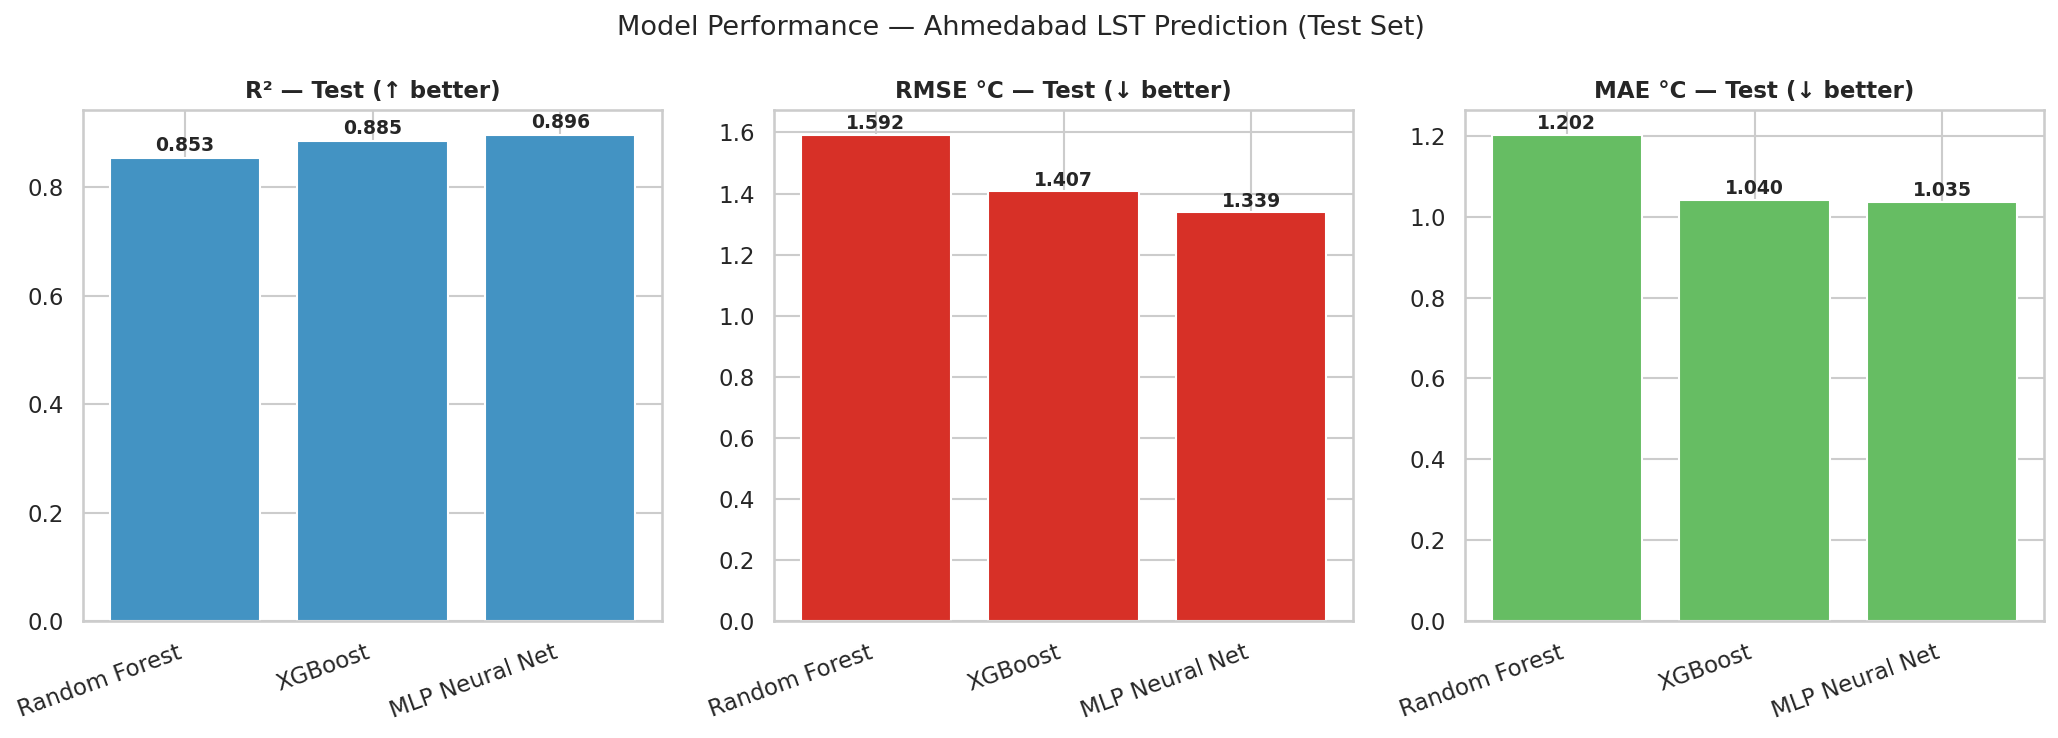


Full comparison table:
         Model  R²_Train  R²_Test  RMSE_Test  MAE_Test
 Random Forest    0.9211   0.8530     1.5922    1.2022
       XGBoost    0.9759   0.8852     1.4070    1.0402
MLP Neural Net    0.9478   0.8961     1.3388    1.0354


In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 15 · MLP Neural Network (sklearn)
# Regularisation: L2 alpha=0.01, early stopping, compact architecture
# ═══════════════════════════════════════════════════════════════════════════

mlp_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,
    batch_size=64,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=25,
    random_state=42,
    verbose=False
)

mlp_model.fit(X_train_sc, y_train)
print(f"MLP trained. Iterations: {mlp_model.n_iter_} | Architecture: {mlp_model.hidden_layer_sizes}")

print("\nMLP Neural Network Evaluation:")
mlp_metrics, mlp_pred = evaluate_model(mlp_model, X_train_sc, y_train, X_test_sc, y_test, 'MLP', scaled=True)

# ── Model Comparison Bar Chart ───────────────────────────────────────────────
comparison_full = pd.DataFrame({
    'Model'     : ['Random Forest', 'XGBoost', 'MLP Neural Net'],
    'R²_Train'  : [rf_metrics['Train']['R²'],  xgb_metrics['Train']['R²'],  mlp_metrics['Train']['R²']],
    'R²_Test'   : [rf_metrics['Test']['R²'],   xgb_metrics['Test']['R²'],   mlp_metrics['Test']['R²']],
    'RMSE_Test' : [rf_metrics['Test']['RMSE'], xgb_metrics['Test']['RMSE'], mlp_metrics['Test']['RMSE']],
    'MAE_Test'  : [rf_metrics['Test']['MAE'],  xgb_metrics['Test']['MAE'],  mlp_metrics['Test']['MAE']],
})

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics_plot = ['R²_Test', 'RMSE_Test', 'MAE_Test']
titles_plot  = ['R² — Test (↑ better)', 'RMSE °C — Test (↓ better)', 'MAE °C — Test (↓ better)']
bar_colors   = ['#4393c3', '#d73027', '#66bd63']

for ax, met, title, clr in zip(axes, metrics_plot, titles_plot, bar_colors):
    bars = ax.bar(comparison_full['Model'], comparison_full[met], color=clr, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xticklabels(comparison_full['Model'], rotation=20, ha='right')
    for bar, val in zip(bars, comparison_full[met]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance — Ahmedabad LST Prediction (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison_ahmedabad.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFull comparison table:")
print(comparison_full.round(4).to_string(index=False))


## 16 · SHAP — Explainability & Feature Importance
> **Why SHAP?** Shapley Additive Explanations (Lundberg & Lee 2017)  
> provide theoretically grounded, game-theoretic feature attribution.  
> Increasingly used in UHI/LST driver analysis (Zhou et al. 2023).


 Computing SHAP values (TreeExplainer)...
 SHAP values computed for 150 samples


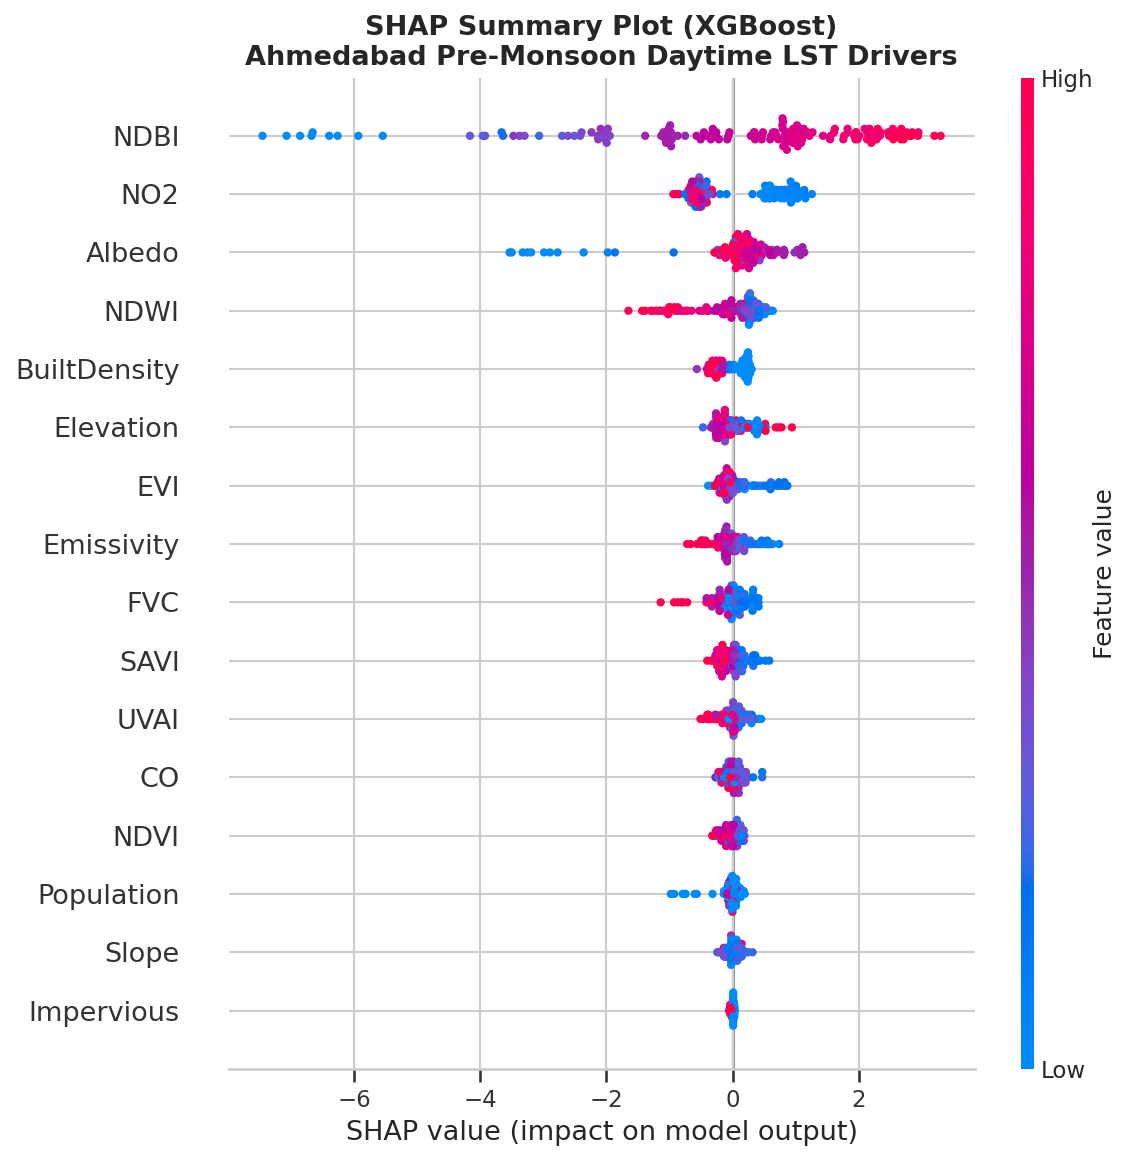

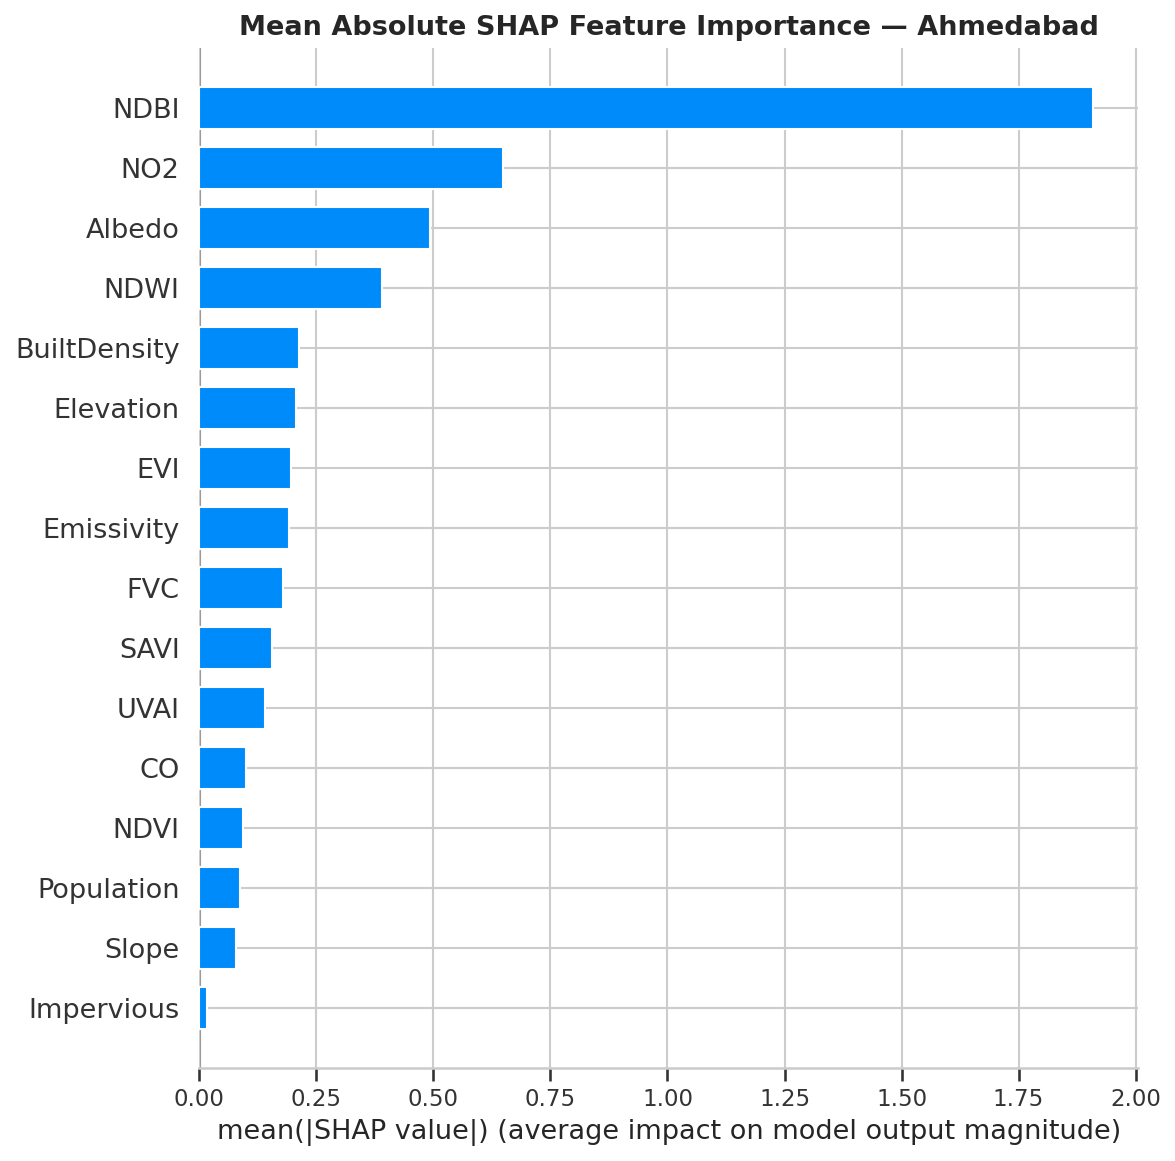

 Plotting dependence for: NDBI


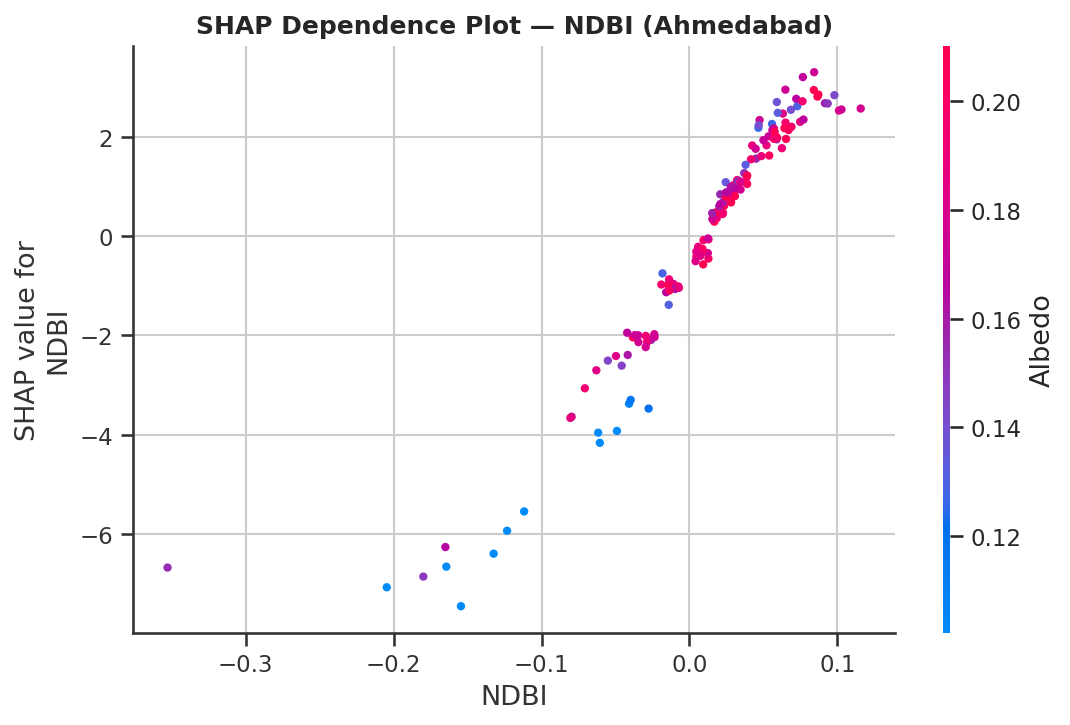

 Plotting dependence for: NO2


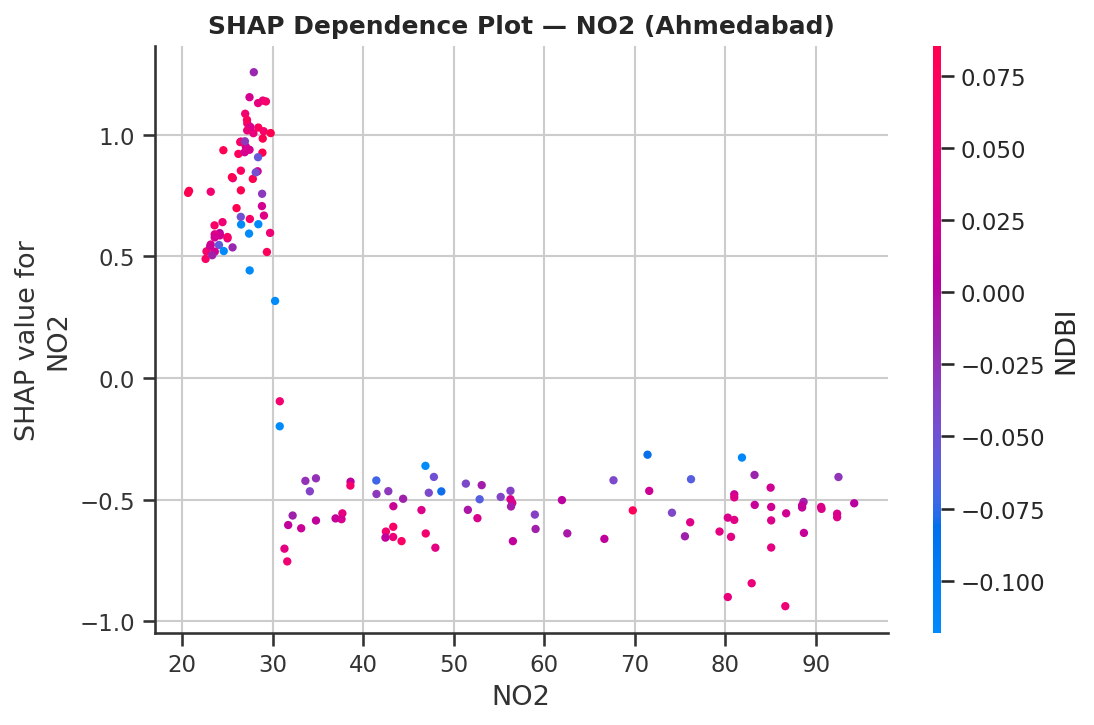

 Plotting dependence for: Albedo


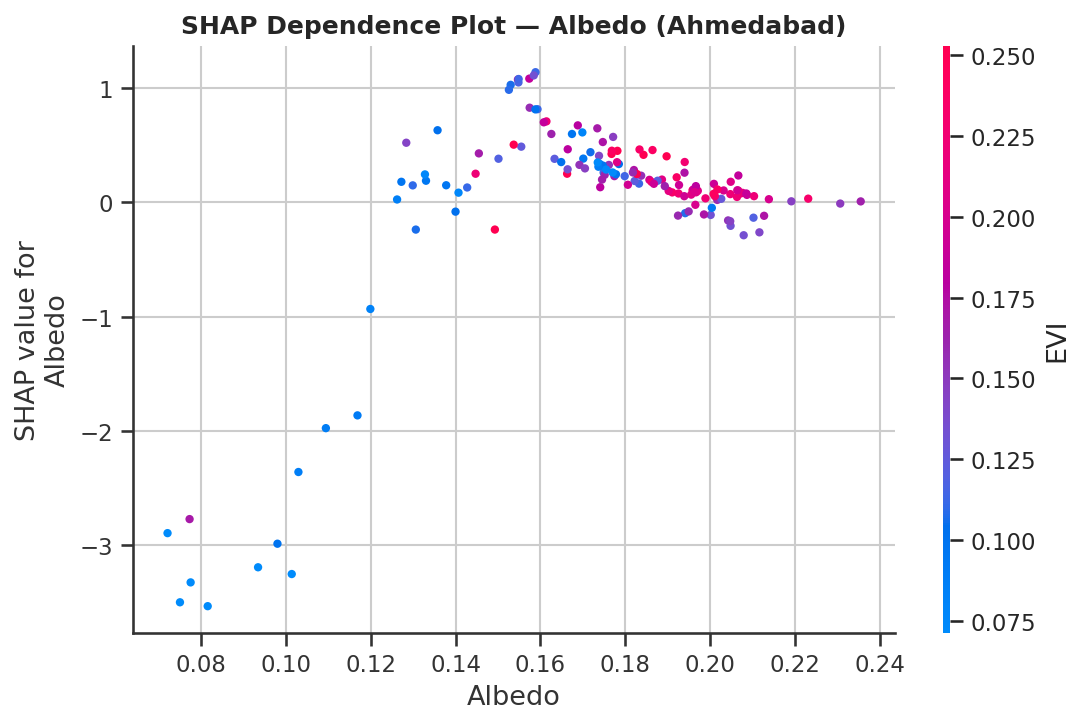

 Plotting dependence for: NDWI


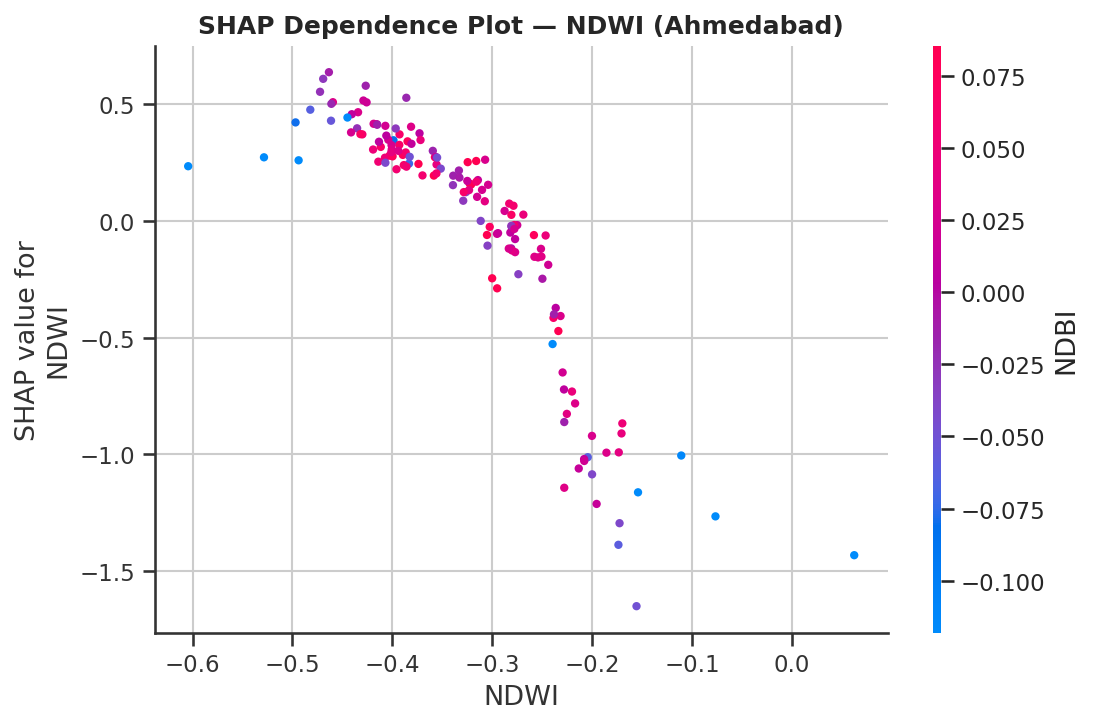


 SHAP Feature Ranking:
01. NDBI                 : 1.9096
02. NO2                  : 0.6481
03. Albedo               : 0.4917
04. NDWI                 : 0.3893
05. BuiltDensity         : 0.2132
06. Elevation            : 0.2065
07. EVI                  : 0.1953
08. Emissivity           : 0.1915
09. FVC                  : 0.1790
10. SAVI                 : 0.1550
11. UVAI                 : 0.1402
12. CO                   : 0.1004
13. NDVI                 : 0.0925
14. Population           : 0.0869
15. Slope                : 0.0773
16. Impervious           : 0.0169

 SHAP outputs saved.


In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# SHAP ANALYSIS ON BEST MODEL (XGBOOST)
# ═══════════════════════════════════════════════════════════════════════════

import shap

print(" Computing SHAP values (TreeExplainer)...")

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer(
    X_test,
    check_additivity=False
)

print(f" SHAP values computed for {len(X_test)} samples")


# ── 1. SHAP Summary Beeswarm Plot ─────────────────────────────────────────
plt.figure(figsize=(8, 6))

shap.summary_plot(
    shap_values, X_test, feature_names=FEATURE_COLS,
    plot_type='dot', max_display=18, show=False
)

plt.title(
    "SHAP Summary Plot (XGBoost)\nAhmedabad Pre-Monsoon Daytime LST Drivers",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('shap_summary_beeswarm_ahmedabad.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 2. SHAP Feature Importance Bar Plot ───────────────────────────────────
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values, X_test, feature_names=FEATURE_COLS,
    plot_type='bar', max_display=18, show=False
)

plt.title("Mean Absolute SHAP Feature Importance — Ahmedabad", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar_plot_ahmedabad.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 3. SHAP Dependence Plots for Top 4 Features ───────────────────────────
mean_shap = np.abs(shap_values.values).mean(axis=0)
top4_idx = np.argsort(mean_shap)[-4:][::-1]
top4_feats = [FEATURE_COLS[i] for i in top4_idx]

for feat in top4_feats:
    print(f" Plotting dependence for: {feat}")
    shap.dependence_plot(
        feat, shap_values.values, X_test,
        feature_names=FEATURE_COLS, show=False
    )
    plt.title(f"SHAP Dependence Plot — {feat} (Ahmedabad)")
    plt.tight_layout()
    plt.savefig(f"shap_dependence_{feat}_ahmedabad.png", dpi=150, bbox_inches='tight')
    plt.show()


# ── 4. Save SHAP Importance Table ─────────────────────────────────────────
shap_df = pd.DataFrame(shap_values.values, columns=FEATURE_COLS)

shap_importance = shap_df.abs().mean().sort_values(ascending=False)

print("\n SHAP Feature Ranking:")
for i, (feat, val) in enumerate(shap_importance.items(), 1):
    print(f"{i:02d}. {feat:<20} : {val:.4f}")

shap_importance.to_csv('shap_feature_importance_ahmedabad.csv')

print("\n SHAP outputs saved.")


## 17 · Publication-Quality Scientific Visualizations

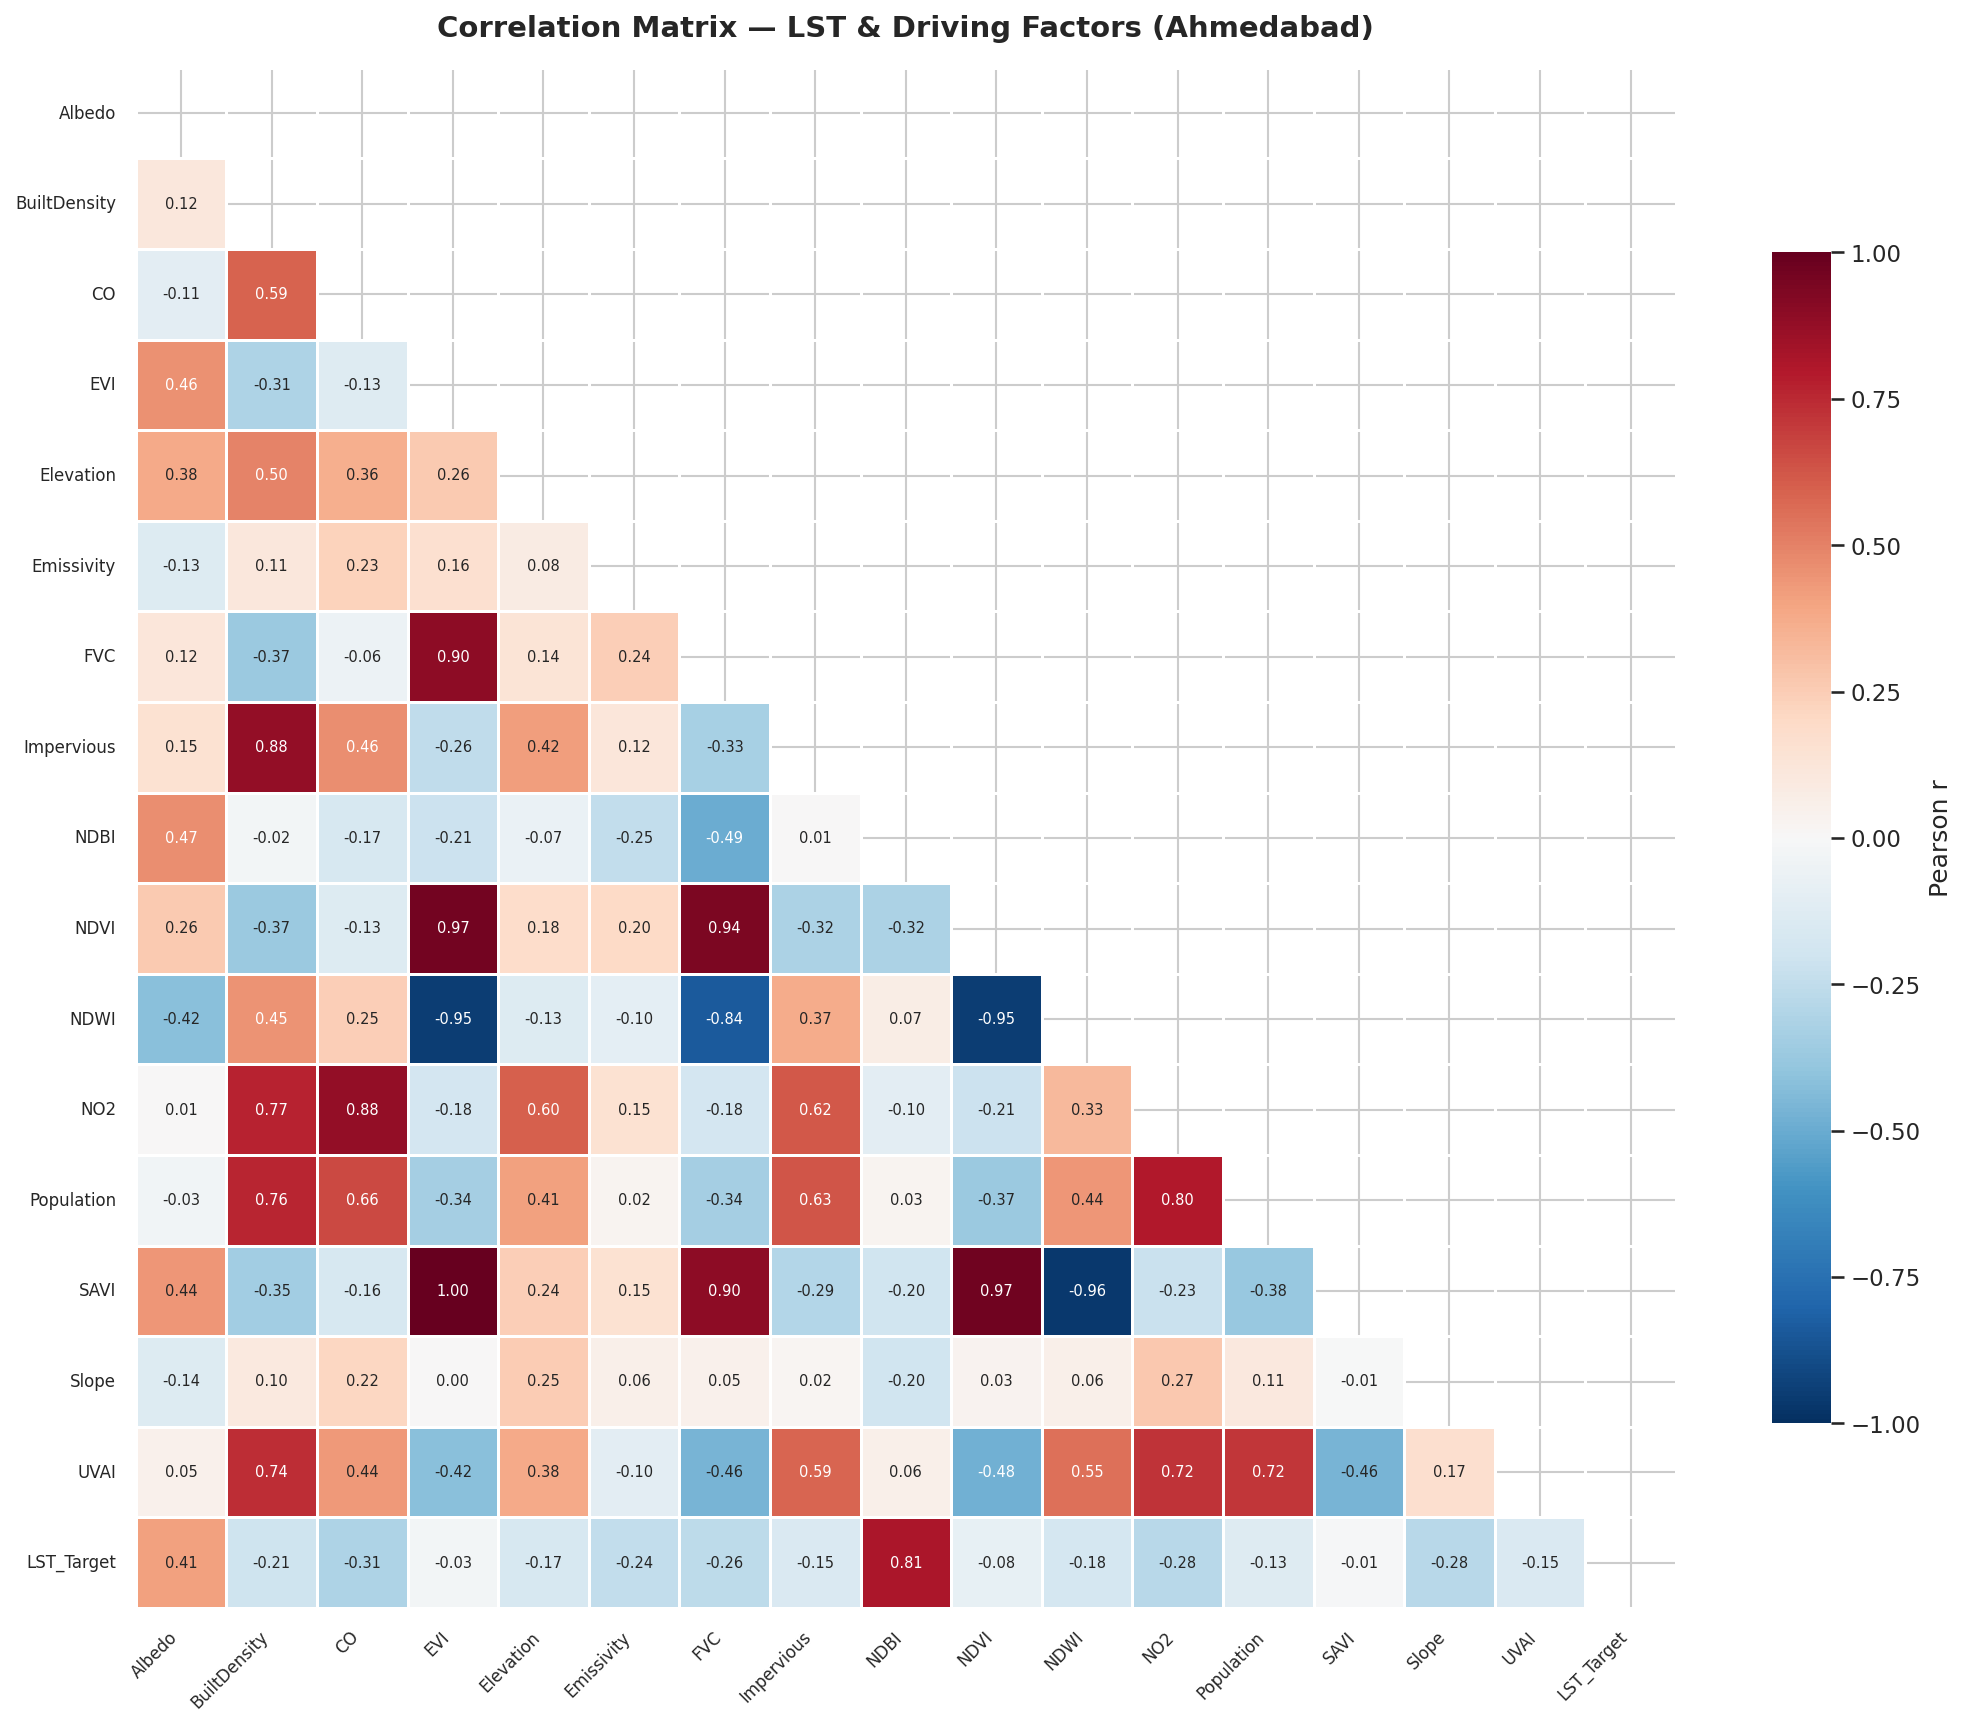

 Saved → correlation_heatmap_ahmedabad.png


In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZATION 1: Correlation Heatmap
# ═══════════════════════════════════════════════════════════════════════════

corr_data = df_raw[FEATURE_COLS + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask_upper = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(corr_data, mask=mask_upper, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, annot=True, fmt='.2f',
            square=True, linewidths=0.5, annot_kws={'size':7},
            cbar_kws={'shrink':0.7, 'label':'Pearson r'}, ax=ax)
ax.set_title('Correlation Matrix — LST & Driving Factors (Ahmedabad)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.savefig('correlation_heatmap_ahmedabad.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → correlation_heatmap_ahmedabad.png")


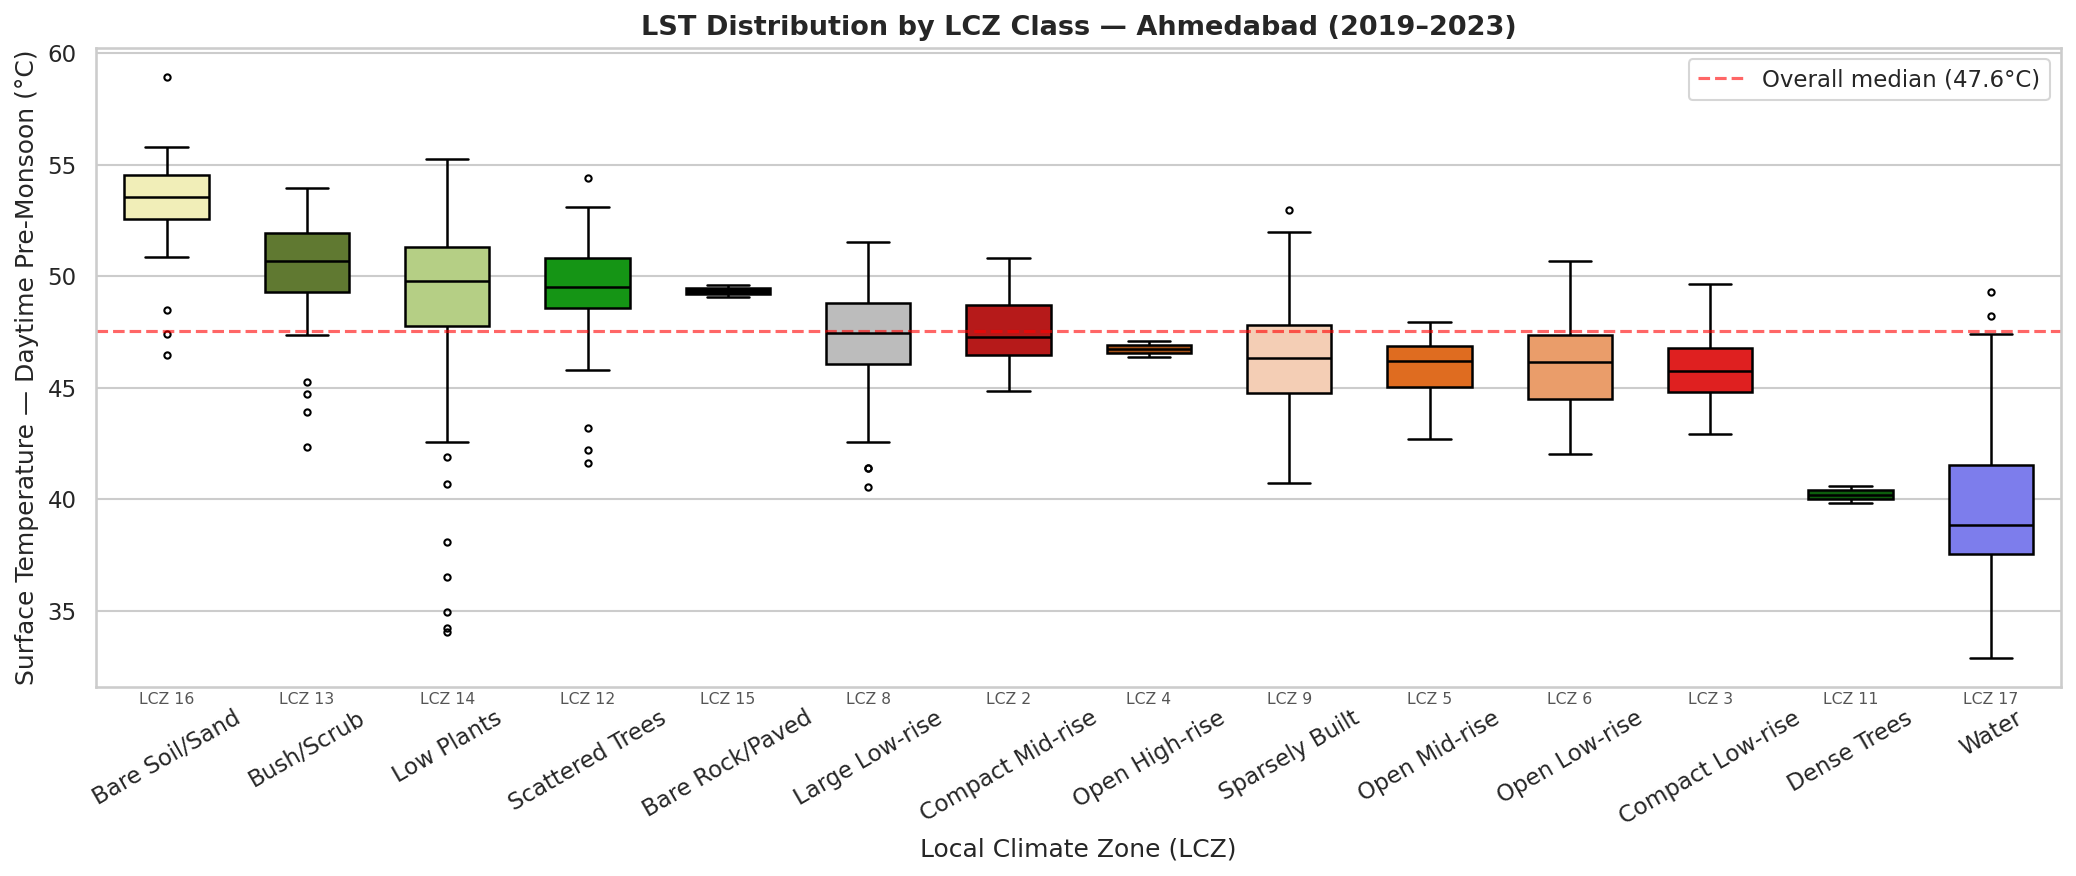

 Saved → lcz_boxplot_lst_ahmedabad.png


In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZATION 2: LCZ Boxplots — LST by LCZ class
# ═══════════════════════════════════════════════════════════════════════════

df_plot = df_raw.copy()
df_plot['LCZ_Name'] = df_plot['LCZ_Class'].map(LCZ_NAMES)
df_plot = df_plot.dropna(subset=['LCZ_Name','LST_Target'])

lcz_order = (df_plot.groupby('LCZ_Name')['LST_Target']
             .median().sort_values(ascending=False).index)

box_palette = {name: LCZ_PALETTE.get(cid,'#aaa')
               for cid, name in LCZ_NAMES.items()
               if name in df_plot['LCZ_Name'].unique()}

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_plot, x='LCZ_Name', y='LST_Target',
            order=lcz_order, palette=box_palette,
            width=0.6, linewidth=1.2, flierprops={'markersize':3}, ax=ax)
ax.set_xlabel('Local Climate Zone (LCZ)', fontsize=12)
ax.set_ylabel('Surface Temperature — Daytime Pre-Monsoon (°C)', fontsize=12)
ax.set_title('LST Distribution by LCZ Class — Ahmedabad (2019–2023)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
for i, name in enumerate(lcz_order):
    cid = [k for k,v in LCZ_NAMES.items() if v==name]
    code_str = str(cid[0]) if cid else ''
    ax.text(i, ax.get_ylim()[0]-0.8, f'LCZ {code_str}',
            ha='center', fontsize=7.5, color='#555555')
ax.axhline(df_plot['LST_Target'].median(), color='red', linestyle='--',
           alpha=0.6, label=f'Overall median ({df_plot["LST_Target"].median():.1f}°C)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('lcz_boxplot_lst_ahmedabad.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → lcz_boxplot_lst_ahmedabad.png")


Available Columns in df_raw:
['Albedo', 'BuiltDensity', 'CO', 'EVI', 'Elevation', 'Emissivity', 'FVC', 'Impervious', 'LCZ_Class', 'LST_Target', 'NDBI', 'NDVI', 'NDWI', 'NO2', 'Population', 'SAVI', 'Slope', 'UVAI']

Using Drivers: ['NDVI', 'NDBI', 'Albedo', 'Impervious', 'Population', 'Elevation']


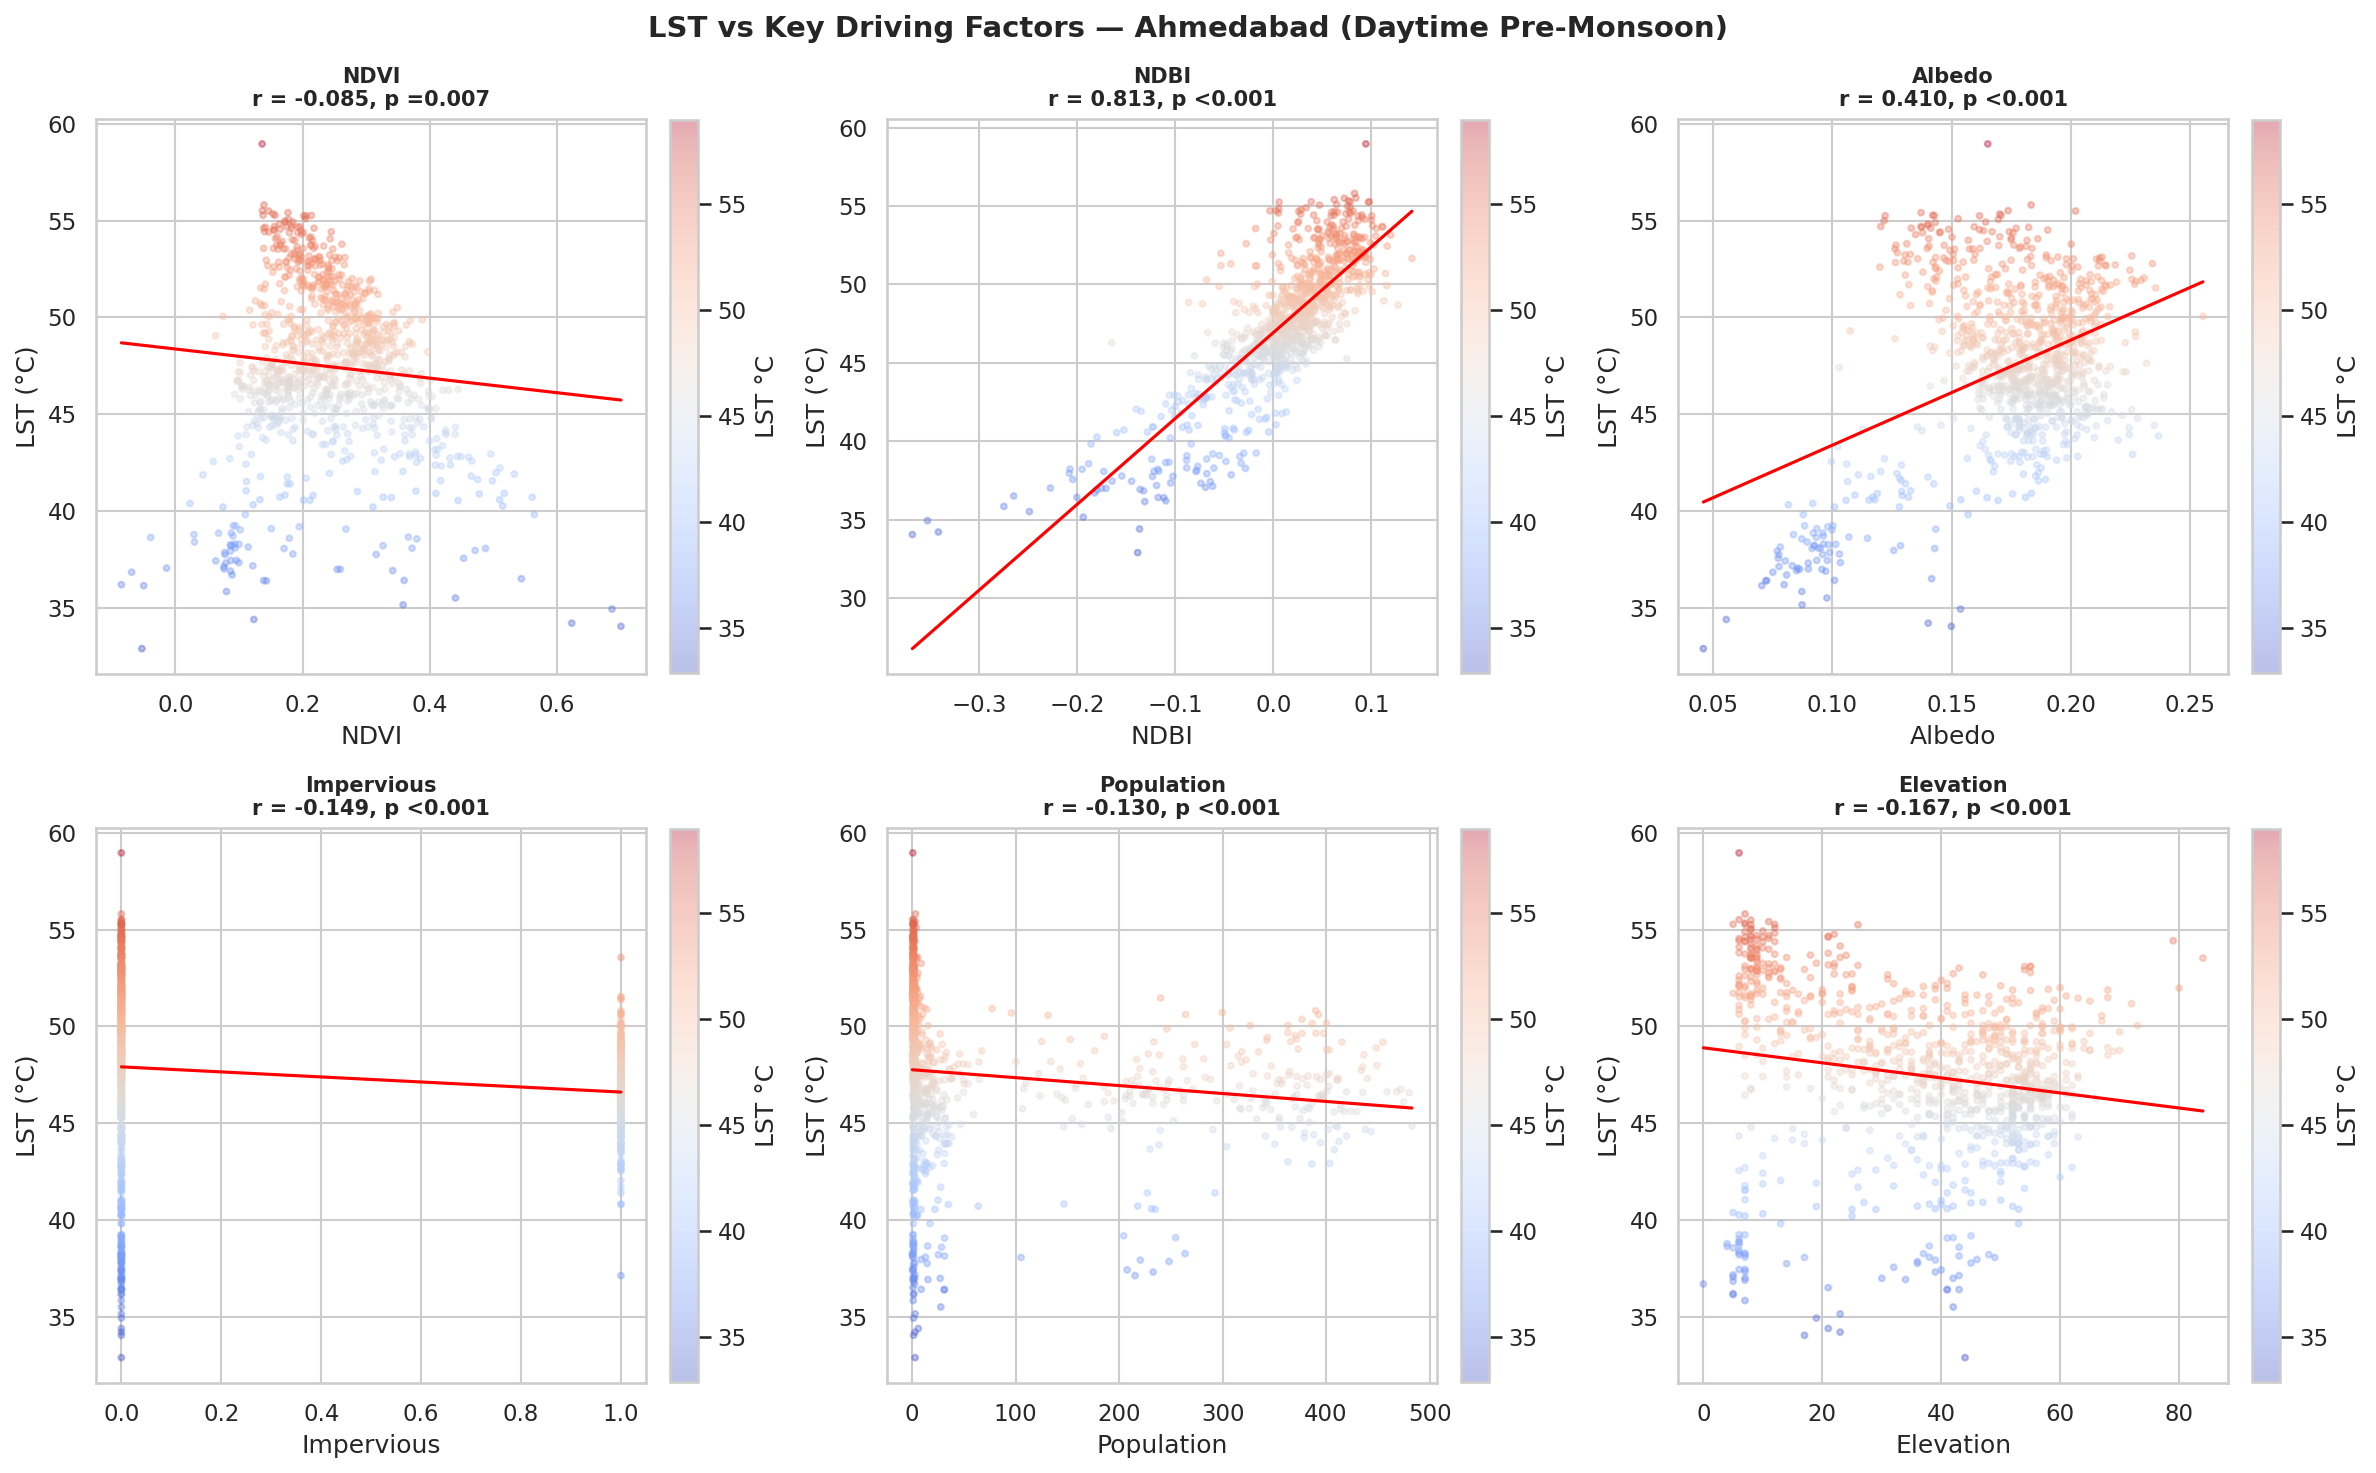

 Saved → lst_driver_scatter_matrix_ahmedabad.png


In [23]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZATION 3: LST vs Key Drivers — Scatter Matrix
# ═══════════════════════════════════════════════════════════════════════════

from scipy.stats import pearsonr

print("Available Columns in df_raw:")
print(df_raw.columns.tolist())

possible_drivers = [
    'NDVI', 'NDBI', 'Albedo',
    'Impervious', 'Population', 'Elevation'
]

key_drivers = [col for col in possible_drivers if col in df_raw.columns]

print("\nUsing Drivers:", key_drivers)

TARGET = 'LST_Target'

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):

    if i >= len(key_drivers):
        ax.axis('off')
        continue

    driver = key_drivers[i]

    x = df_raw[driver].values
    y_ = df_raw[TARGET].values

    valid = ~(np.isnan(x) | np.isnan(y_))
    x = x[valid]; y_ = y_[valid]

    if len(x) < 5:
        ax.text(0.5, 0.5, 'Insufficient\nData', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        continue

    r, p = pearsonr(x, y_)
    sc = ax.scatter(x, y_, c=y_, cmap='coolwarm', alpha=0.35, s=8)

    z = np.polyfit(x, y_, 1)
    pfit = np.poly1d(z)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, pfit(xr), color='red', linewidth=1.5)

    ax.set_xlabel(driver)
    ax.set_ylabel('LST (°C)')

    p_text = "<0.001" if p < 0.001 else f"={p:.3f}"
    ax.set_title(f"{driver}\nr = {r:.3f}, p {p_text}", fontsize=10, fontweight='bold')
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04).set_label('LST °C')

for j in range(len(key_drivers), 6):
    axes[j].axis('off')

plt.suptitle(
    'LST vs Key Driving Factors — Ahmedabad (Daytime Pre-Monsoon)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('lst_driver_scatter_matrix_ahmedabad.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → lst_driver_scatter_matrix_ahmedabad.png")


Fetching UHI comparison data (4 GEE calls total)...
                   Day-Summer  Night-Summer  Day-Winter  Night-Winter
Compact High-rise         NaN           NaN         NaN           NaN
Compact Mid-rise        -2.31          8.12        0.59          3.63
Compact Low-rise        -4.09          7.52       -0.04          3.32
Open Mid-rise           -4.40           NaN       -0.76           NaN
Open Low-rise           -3.60          4.15       -0.39          1.60
Large Low-rise          -2.65          5.01        0.48          2.19
Dense Trees            -10.88           NaN       -3.31           NaN
Low Plants              -1.02          0.16       -0.02         -0.13
Water                  -14.08          2.55       -6.25          1.66


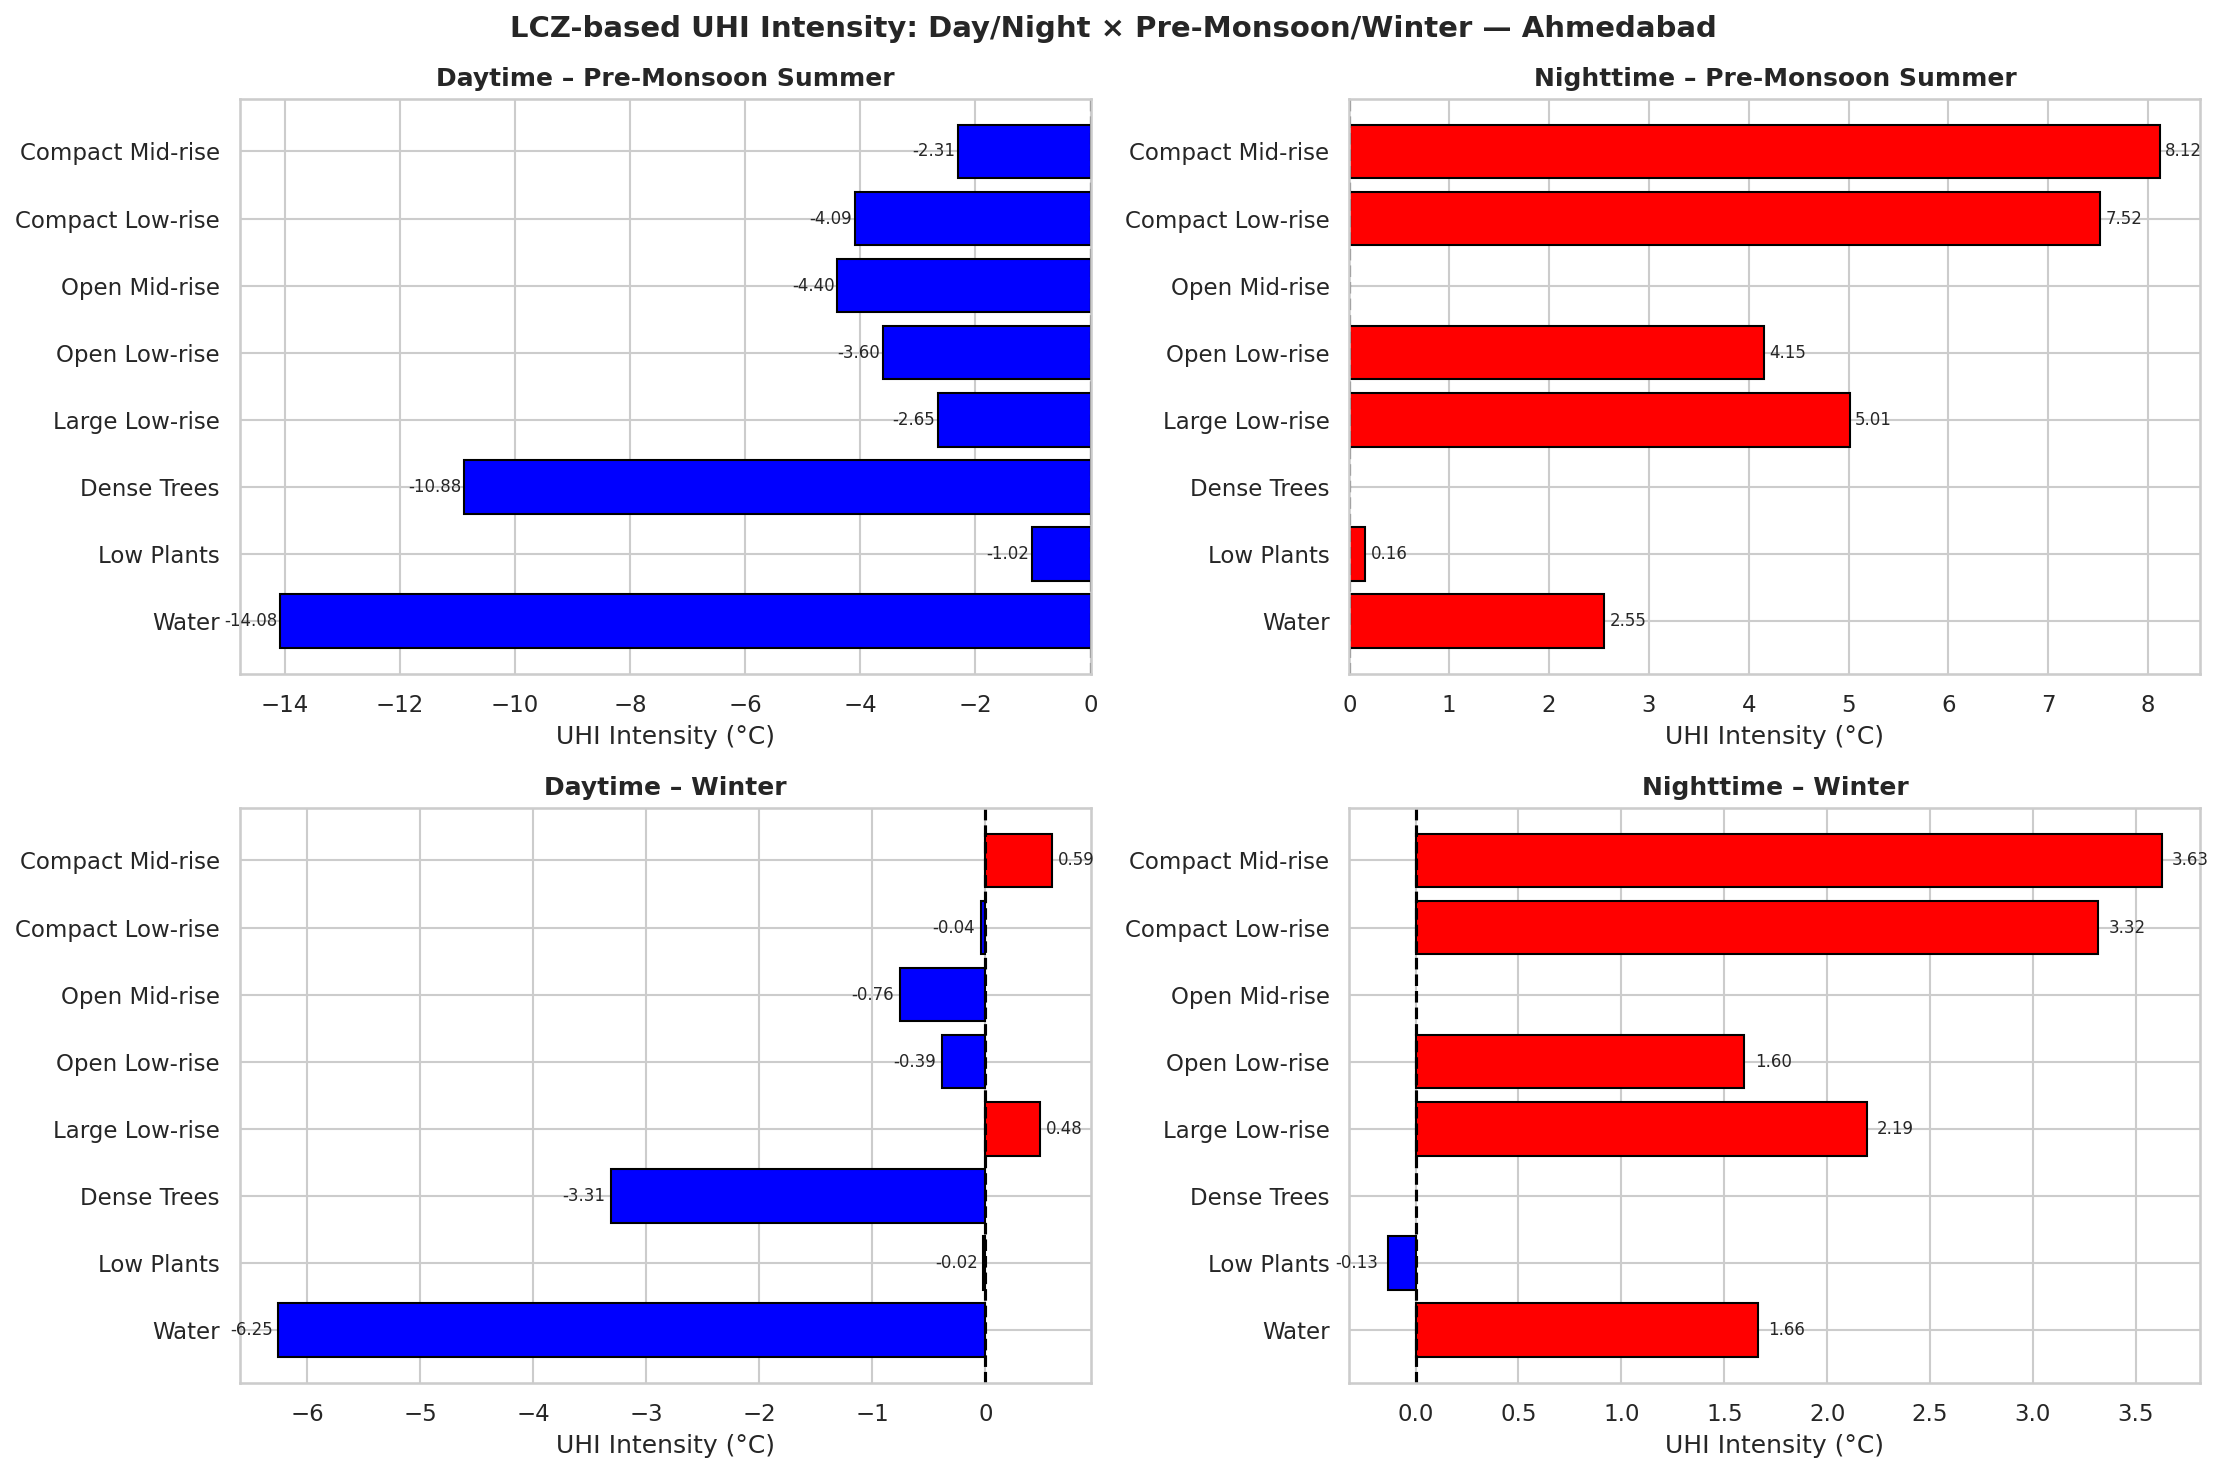

 Saved → uhi_comparison_daynightseasonal_ahmedabad.png


In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZATION 4: Day/Night & Summer/Winter UHI Comparison
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def get_uhi_mean_by_lcz(uhi_img, lcz_ids=None):

    if lcz_ids is None:
        lcz_ids = [1,2,3,5,6,8,11,14,17]

    if uhi_img is None:
        return [np.nan]*len(lcz_ids)

    try:
        _is_night = uhi_img.bandNames().get(0).getInfo().startswith('UHI_Night')
        _scale    = 1000 if _is_night else 100

        grouped = (
            uhi_img.rename('uhi')
            .addBands(lcz_map.rename('lcz'))
            .reduceRegion(
                reducer=ee.Reducer.mean().group(groupField=1),
                geometry=roi, scale=_scale,
                maxPixels=1e13, bestEffort=True, tileScale=4
            )
            .get('groups')
            .getInfo()
        )

        if grouped is None:
            return [np.nan]*len(lcz_ids)

        val_map = {int(g['group']): g['mean'] for g in grouped}

        return [val_map.get(cid, np.nan) for cid in lcz_ids]

    except Exception as ex:
        print(f'⚠ grouped reduceRegion failed: {ex}')
        return [np.nan]*len(lcz_ids)


print('Fetching UHI comparison data (4 GEE calls total)...')

lcz_ids  = [1,2,3,5,6,8,11,14,17]
lcz_lbls = [LCZ_NAMES[i] for i in lcz_ids]

uhi_scenarios = {
    'Day-Summer'  : get_uhi_mean_by_lcz(uhi_day_summer),
    'Night-Summer': get_uhi_mean_by_lcz(uhi_night_summer),
    'Day-Winter'  : get_uhi_mean_by_lcz(uhi_day_winter),
    'Night-Winter': get_uhi_mean_by_lcz(uhi_night_winter),
}

df_uhi_comp = pd.DataFrame(uhi_scenarios, index=lcz_lbls)
print(df_uhi_comp.round(2))


fig, axes = plt.subplots(2, 2, figsize=(15, 10))

titles = [
    'Daytime – Pre-Monsoon Summer',
    'Nighttime – Pre-Monsoon Summer',
    'Daytime – Winter',
    'Nighttime – Winter'
]

for ax, scen, title in zip(axes.flat, df_uhi_comp.columns, titles):

    vals = df_uhi_comp[scen].values
    colors = ['red' if v > 0 else 'blue' for v in np.nan_to_num(vals)]

    bars = ax.barh(lcz_lbls[::-1], vals[::-1], color=colors[::-1], edgecolor='black')
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('UHI Intensity (°C)')

    for bar, val in zip(bars, vals[::-1]):
        if not np.isnan(val):
            ax.text(
                val + 0.05 if val >= 0 else val - 0.05,
                bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=8
            )

plt.suptitle(
    'LCZ-based UHI Intensity: Day/Night × Pre-Monsoon/Winter — Ahmedabad',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('uhi_comparison_daynightseasonal_ahmedabad.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved → uhi_comparison_daynightseasonal_ahmedabad.png')


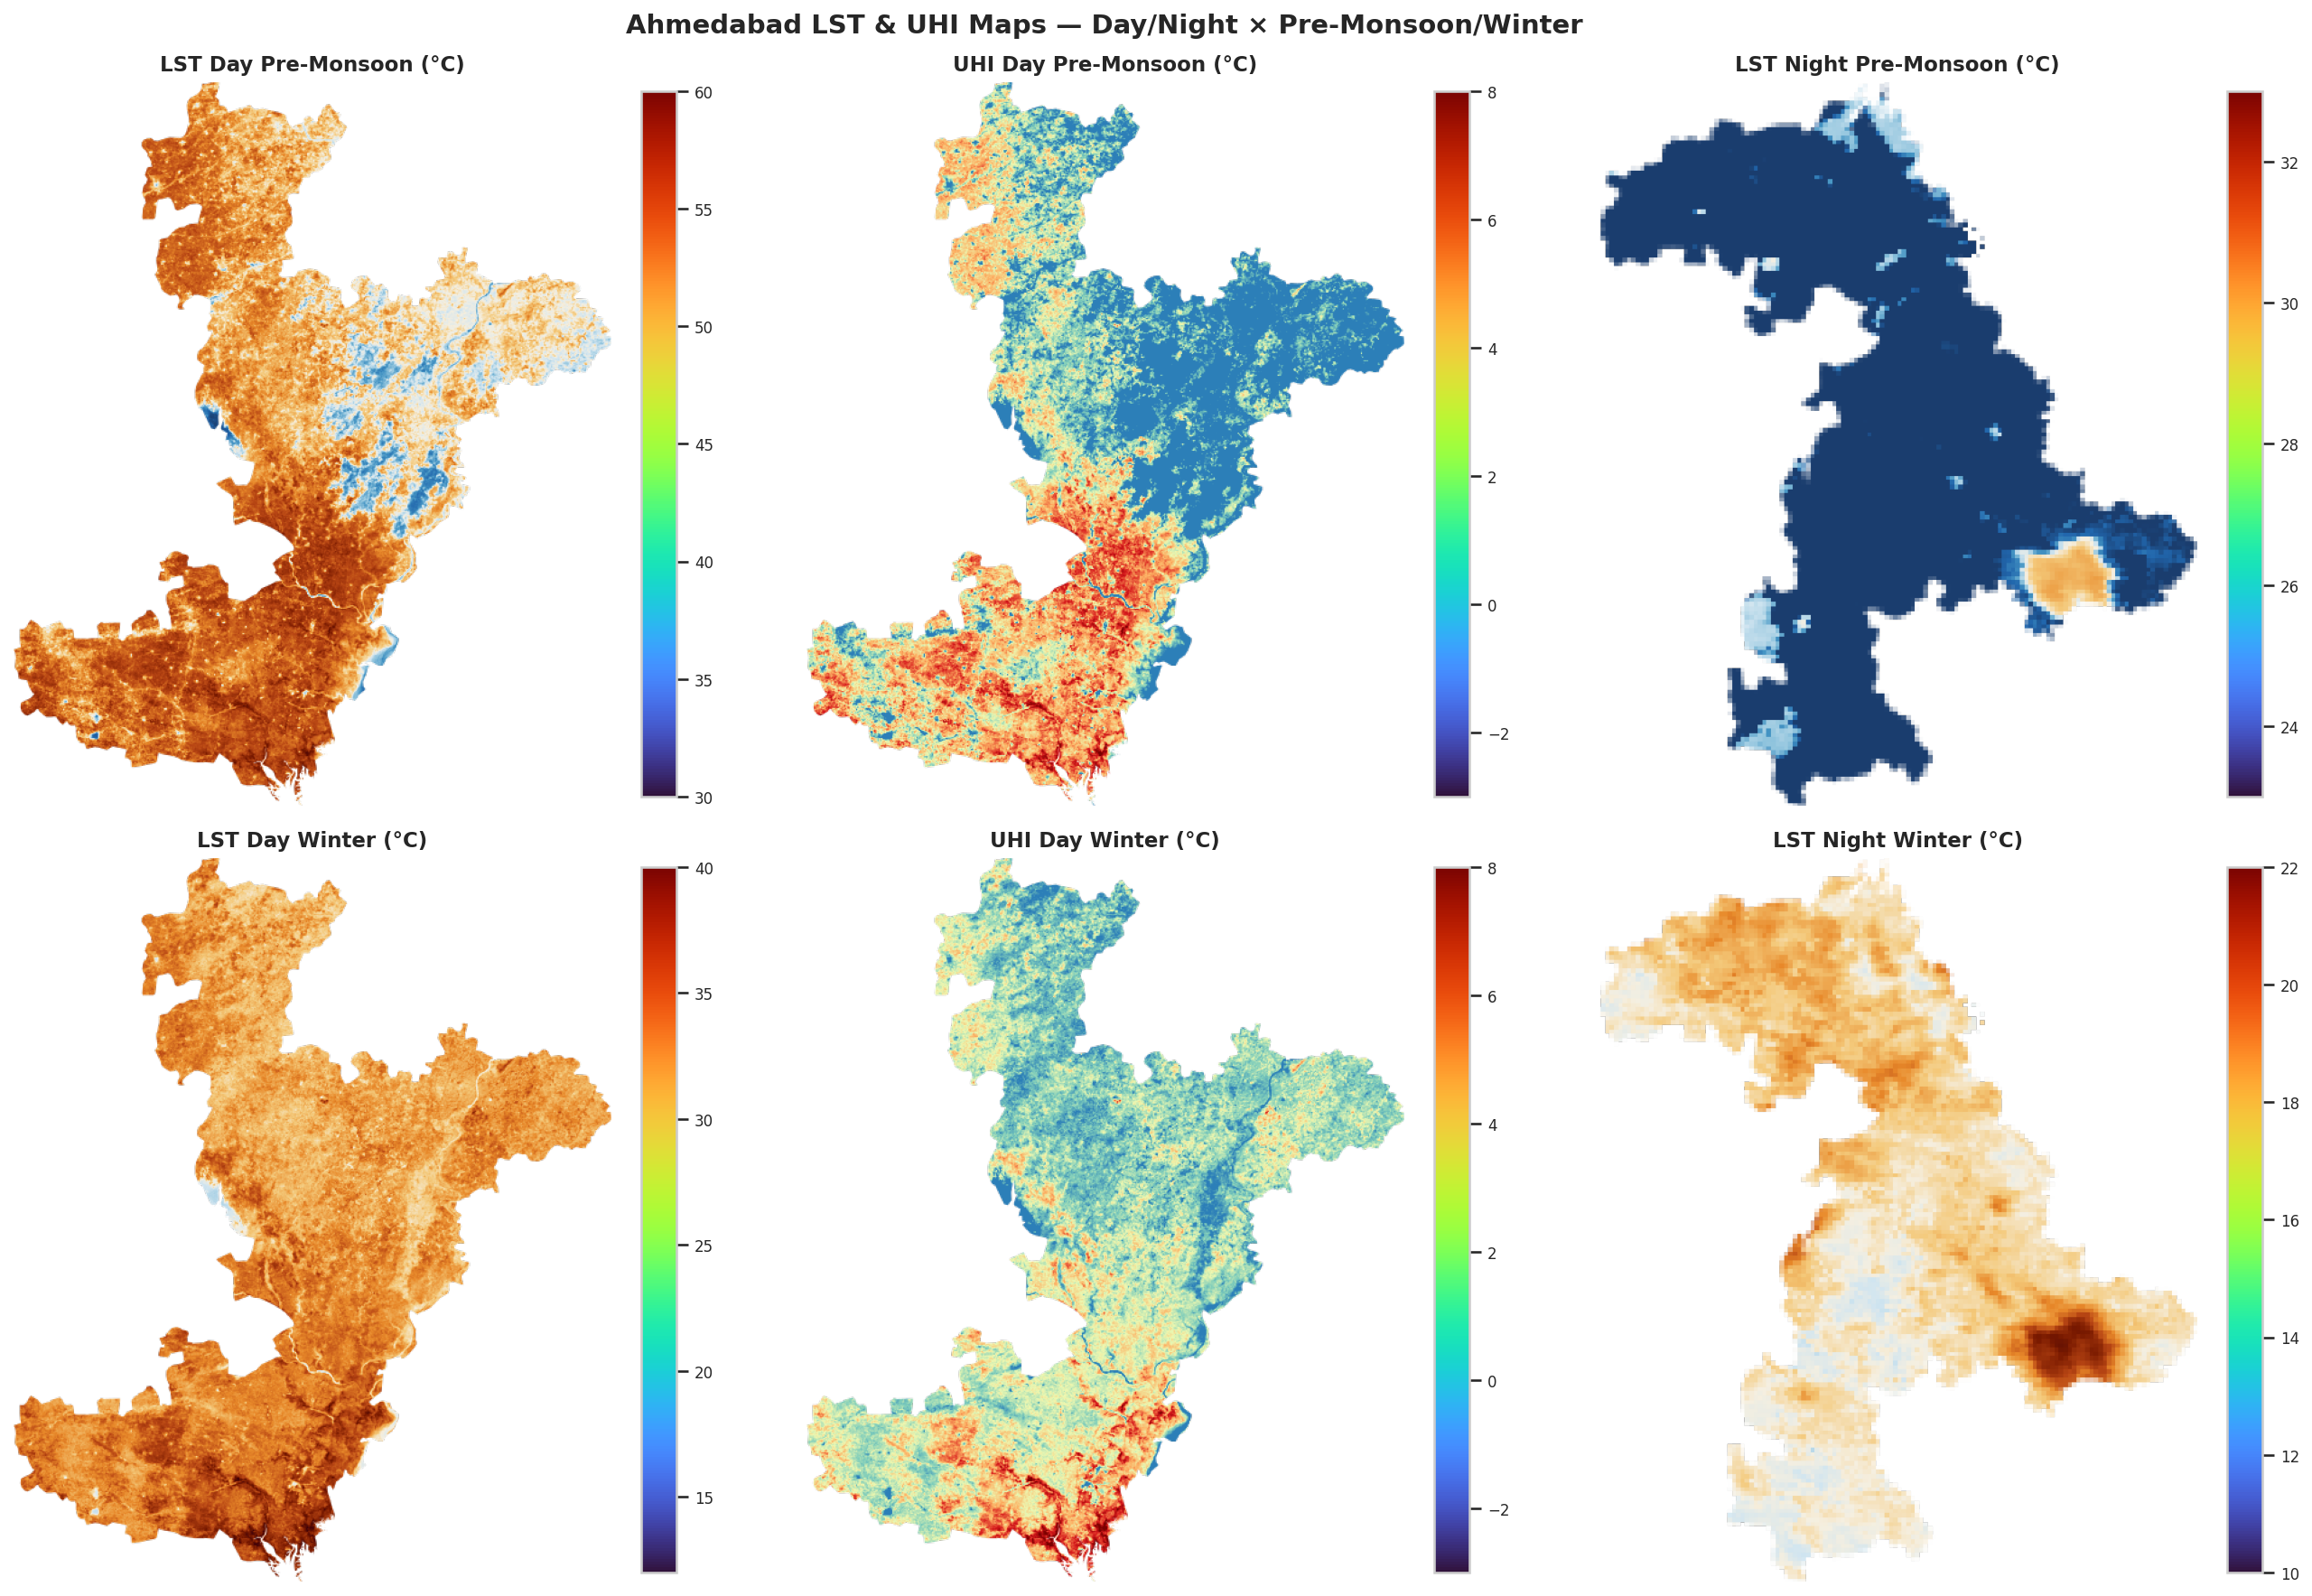

Saved → spatial_lst_uhi_maps_ahmedabad.png


In [25]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZATION 5: Spatial UHI Maps (2×3 grid)
# Ahmedabad-specific LST ranges
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib as mpl
import urllib.request
from PIL import Image as PILImage
import io

# ── VIS PARAMS — Ahmedabad temperature ranges ──────────────────────────────
uhi_vis = {'min': -3, 'max': 8, 'palette': GEE_UHI_PALETTE}

lst_vis_day_summer   = {'min': 30, 'max': 60, 'palette': GEE_LST_PALETTE}
lst_vis_day_winter   = {'min': 12, 'max': 40, 'palette': GEE_LST_PALETTE}
lst_vis_night_summer = {'min': 23, 'max': 33, 'palette': GEE_LST_PALETTE}
lst_vis_night_winter = {'min': 10, 'max': 22, 'palette': GEE_LST_PALETTE}

scenarios = [
    ('LST Day Pre-Monsoon (°C)',   lst_day_summer,   lst_vis_day_summer),
    ('UHI Day Pre-Monsoon (°C)',   uhi_day_summer,   uhi_vis),
    ('LST Night Pre-Monsoon (°C)', lst_night_summer, lst_vis_night_summer),
    ('LST Day Winter (°C)',        lst_day_winter,   lst_vis_day_winter),
    ('UHI Day Winter (°C)',        uhi_day_winter,   uhi_vis),
    ('LST Night Winter (°C)',      lst_night_winter, lst_vis_night_winter),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, (title, img, vis) in zip(axes.flat, scenarios):

    try:
        url = img.visualize(**vis).getThumbURL({
            'region': roi.bounds(maxError=100),
            'dimensions': 600,
            'format': 'png'
        })

        with urllib.request.urlopen(url) as resp:
            thumb = PILImage.open(io.BytesIO(resp.read()))

        ax.imshow(thumb)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.axis('off')

        norm = mpl.colors.Normalize(vmin=vis['min'], vmax=vis['max'])
        sm = mpl.cm.ScalarMappable(norm=norm, cmap='turbo')
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)

    except Exception as e:
        print(f"FAILED: {title} -> {e}")
        ax.text(0.5, 0.5, "Render Failed",
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

plt.suptitle(
    'Ahmedabad LST & UHI Maps — Day/Night × Pre-Monsoon/Winter',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('spatial_lst_uhi_maps_ahmedabad.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → spatial_lst_uhi_maps_ahmedabad.png")


## 18 · Spatial Prediction — ML-Derived UHI Risk Map
> Apply the trained XGBoost model to the entire Ahmedabad extent (every 30m pixel)  
> to produce a spatially explicit predicted LST / UHI risk raster.


Building GEE spatial prediction stack...

Predicted LST — Mean: 49.58°C | Std: 3.76°C
Rural reference LST (LCZ 11 median): 39.44°C
Predicted UHI — Mean: 10.15°C | Max: 15.57°C


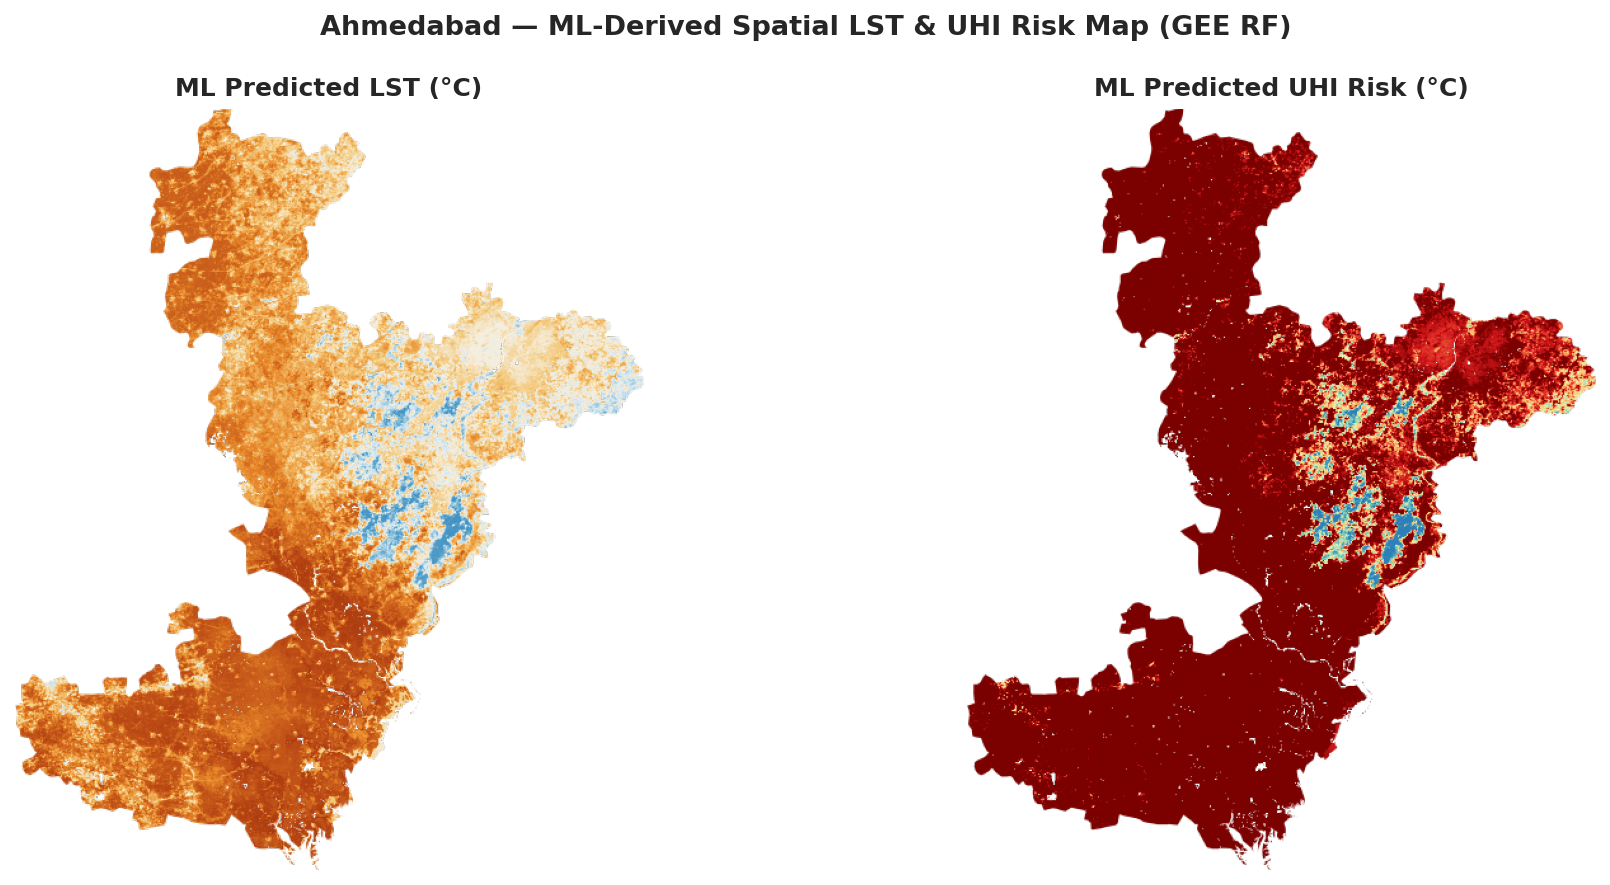

Saved → ml_spatial_uhi_map_ahmedabad.png


In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 18 · Spatial Prediction — GEE RF for UHI Risk Mapping
# ═══════════════════════════════════════════════════════════════════════════

print("Building GEE spatial prediction stack...")

pred_feature_stack = (
    summer_composite.select([
        'NDVI', 'NDBI', 'NDWI', 'SAVI', 'EVI', 'Albedo'
    ])
    .addBands(emis_s.rename('Emissivity'))
    .addBands(fv_s.rename('FVC'))
    .addBands(elev.rename('Elevation'))
    .addBands(slope.rename('Slope'))
    .addBands(population.rename('Population'))
    .addBands(impervious.rename('Impervious'))
    .addBands(built_density.rename('BuiltDensity'))
    .addBands(no2_summer.rename('NO2'))
    .addBands(co_summer.rename('CO'))
    .addBands(uvai_summer.rename('UVAI'))
)

PRED_SCALE = 300

gee_training_stack = (
    pred_feature_stack
    .addBands(lst_day_summer.rename('LST_Target'))
)

gee_samples = gee_training_stack.sample(
    region=roi, scale=PRED_SCALE, numPixels=3000,
    seed=42, geometries=False, tileScale=8
)

PRED_BANDS = pred_feature_stack.bandNames()

gee_rf = (
    ee.Classifier.smileRandomForest(
        numberOfTrees=200, minLeafPopulation=10,
        bagFraction=0.7, seed=42
    )
    .setOutputMode('REGRESSION')
    .train(
        features=gee_samples,
        classProperty='LST_Target',
        inputProperties=PRED_BANDS
    )
)

predicted_lst_map = (
    pred_feature_stack
    .classify(gee_rf)
    .rename('Predicted_LST')
    .clip(roi)
)

rural_lst_pred = (
    predicted_lst_map
    .updateMask(lcz_map.eq(11))
    .reduceRegion(
        reducer=ee.Reducer.median(), geometry=roi,
        scale=PRED_SCALE, maxPixels=1e13, bestEffort=True, tileScale=4
    )
    .get('Predicted_LST')
)

predicted_uhi_map = (
    predicted_lst_map
    .subtract(ee.Number(rural_lst_pred))
    .rename('Predicted_UHI')
    .clip(roi)
)

pred_stats = predicted_lst_map.reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.stdDev(),'',True),
    geometry=roi, scale=PRED_SCALE, maxPixels=1e13, bestEffort=True, tileScale=4
).getInfo()

rural_val = ee.Number(rural_lst_pred).getInfo()
print(f"\nPredicted LST — Mean: {pred_stats.get('Predicted_LST_mean','N/A'):.2f}°C | Std: {pred_stats.get('Predicted_LST_stdDev','N/A'):.2f}°C")
print(f"Rural reference LST (LCZ 11 median): {rural_val:.2f}°C")

uhi_stats = predicted_uhi_map.reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.max(),'',True),
    geometry=roi, scale=PRED_SCALE, maxPixels=1e13, bestEffort=True, tileScale=4
).getInfo()

print(f"Predicted UHI — Mean: {uhi_stats.get('Predicted_UHI_mean','N/A'):.2f}°C | Max: {uhi_stats.get('Predicted_UHI_max','N/A'):.2f}°C")

# ── Visualisation ──────────────────────────────────────────────────────────
import urllib.request
from PIL import Image as PILImage
import io

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (img, vis, title) in zip(axes, [
    (predicted_lst_map, {'min':30,'max':60,'palette':GEE_LST_PALETTE}, 'ML Predicted LST (°C)'),
    (predicted_uhi_map, {'min':-3,'max':8, 'palette':GEE_UHI_PALETTE}, 'ML Predicted UHI Risk (°C)')
]):
    try:
        url = img.visualize(**vis).getThumbURL({
            'region': roi.bounds(maxError=100), 'dimensions': 600, 'format': 'png'
        })
        with urllib.request.urlopen(url) as resp:
            thumb = PILImage.open(io.BytesIO(resp.read()))
        ax.imshow(thumb)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')
    except Exception as e:
        ax.text(0.5, 0.5, f"Render failed:\n{e}", ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

plt.suptitle('Ahmedabad — ML-Derived Spatial LST & UHI Risk Map (GEE RF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ml_spatial_uhi_map_ahmedabad.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ml_spatial_uhi_map_ahmedabad.png")


## 19 · GeoTIFF Export (Google Drive)
> All outputs exported as GeoTIFF at 30m/100m resolution to Google Drive.  
> Check progress at: https://code.earthengine.google.com/tasks


In [27]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 19 · GeoTIFF Export to Google Drive
# ═══════════════════════════════════════════════════════════════════════════

import ee

DRIVE_FOLDER = 'Ahmedabad_UHI_Outputs'

# Ahmedabad lies in UTM Zone 43N
CRS = 'EPSG:32643'

MAX_PIX = 1e13
SCALE_30  = 30
SCALE_100 = 100

export_tasks = {}

def export_image(image, name, scale=SCALE_30, skip_on_error=True):

    if image is None:
        print(f"⚠ {name} skipped — image is None")
        return None

    try:
        task = ee.batch.Export.image.toDrive(
            image=image.toFloat(),
            description=name[:100],
            folder=DRIVE_FOLDER,
            fileNamePrefix=name,
            region=roi.bounds(maxError=100),
            scale=scale,
            crs=CRS,
            maxPixels=MAX_PIX,
            fileFormat='GeoTIFF',
            formatOptions={'cloudOptimized': True},
        )
        task.start()
        export_tasks[name] = task
        print(f"✅ {name} ({scale} m)")
        return task

    except Exception as e:
        print(f"❌ {name}")
        print(e)
        if not skip_on_error:
            raise
        return None


print(f"\nSubmitting exports → Google Drive folder: '{DRIVE_FOLDER}'\n")

print("── 1. LST Maps")
export_image(lst_day_summer,   'LST_Day_Summer_30m')
export_image(lst_day_winter,   'LST_Day_Winter_30m')
export_image(lst_night_summer, 'LST_Night_Summer_30m')
export_image(lst_night_winter, 'LST_Night_Winter_30m')

print("── 2. UHI Maps")
export_image(uhi_day_summer,   'UHI_Day_Summer_30m')
export_image(uhi_night_summer, 'UHI_Night_Summer_30m')
export_image(uhi_day_winter,   'UHI_Day_Winter_30m')
export_image(uhi_night_winter, 'UHI_Night_Winter_30m')

print("── 3. LCZ")
export_image(lcz_map.toFloat(), 'LCZ_Map_30m')

print("── 4. TROPOMI")
for name, img in [
    ('TROPOMI_NO2_Summer_100m',  no2_summer),
    ('TROPOMI_NO2_Winter_100m',  no2_winter),
    ('TROPOMI_CO_Summer_100m',   co_summer),
    ('TROPOMI_CO_Winter_100m',   co_winter),
    ('TROPOMI_UVAI_Summer_100m', uvai_summer),
    ('TROPOMI_UVAI_Winter_100m', uvai_winter),
]:
    export_image(img, name, scale=SCALE_100)

print("── 5. Driving Factors")
factor_exports = {
    'NDVI_Summer': ndvi_s, 'NDBI_Summer': ndbi_s, 'NDWI_Summer': ndwi_s,
    'Albedo_Summer': albedo_s, 'EVI_Summer': evi_s, 'BSI_Summer': bsi_s,
    'Emissivity': emis_s, 'VegFraction': fv_s,
    'Elevation_SRTM': elev, 'Slope': slope, 'TWI': twi,
    'Population': population, 'Impervious': impervious,
    'BuiltDensity': built_density, 'DistWater': dist_water,
    'DistGreen': dist_green, 'SVF_Proxy': svf_proxy,
}
for fname, img in factor_exports.items():
    export_image(img, f'Factor_{fname}_100m', scale=SCALE_100)

print("── 6. ML Predictions")
export_image(predicted_lst_map, 'ML_Predicted_LST_100m', scale=SCALE_100)
export_image(predicted_uhi_map, 'ML_Predicted_UHI_Risk_100m', scale=SCALE_100)

submitted = len(export_tasks)
print(f"\n✅ {submitted} tasks submitted successfully")
print("Monitor exports: https://code.earthengine.google.com/tasks")
print(f"\nFiles will appear in Google Drive → '{DRIVE_FOLDER}'")



Submitting exports → Google Drive folder: 'Ahmedabad_UHI_Outputs'

── 1. LST Maps
✅ LST_Day_Summer_30m (30 m)
✅ LST_Day_Winter_30m (30 m)
✅ LST_Night_Summer_30m (30 m)
✅ LST_Night_Winter_30m (30 m)
── 2. UHI Maps
✅ UHI_Day_Summer_30m (30 m)
✅ UHI_Night_Summer_30m (30 m)
✅ UHI_Day_Winter_30m (30 m)
✅ UHI_Night_Winter_30m (30 m)
── 3. LCZ
✅ LCZ_Map_30m (30 m)
── 4. TROPOMI
✅ TROPOMI_NO2_Summer_100m (100 m)
✅ TROPOMI_NO2_Winter_100m (100 m)
✅ TROPOMI_CO_Summer_100m (100 m)
✅ TROPOMI_CO_Winter_100m (100 m)
✅ TROPOMI_UVAI_Summer_100m (100 m)
✅ TROPOMI_UVAI_Winter_100m (100 m)
── 5. Driving Factors
✅ Factor_NDVI_Summer_100m (100 m)
✅ Factor_NDBI_Summer_100m (100 m)
✅ Factor_NDWI_Summer_100m (100 m)
✅ Factor_Albedo_Summer_100m (100 m)
✅ Factor_EVI_Summer_100m (100 m)
✅ Factor_BSI_Summer_100m (100 m)
✅ Factor_Emissivity_100m (100 m)
✅ Factor_VegFraction_100m (100 m)
✅ Factor_Elevation_SRTM_100m (100 m)
✅ Factor_Slope_100m (100 m)
✅ Factor_TWI_100m (100 m)
✅ Factor_Population_100m (100 m)
✅ Fa

## 20 · Final Statistical Analysis & Summary

In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE STATISTICAL ANALYSIS — AHMEDABAD
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  AHMEDABAD UHI/SUHI ANALYSIS — FINAL STATISTICAL SUMMARY")
print("=" * 65)

# ── 1. Model performance summary ────────────────────────────────────────────
print("\n MACHINE LEARNING MODEL PERFORMANCE (Test Set):")
print("-" * 50)
models_summary = [
    ('Random Forest',  rf_metrics),
    ('XGBoost',        xgb_metrics),
    ('MLP Neural Net', mlp_metrics),
]
for name, m in models_summary:
    print(f"  {name:<18} R²={m['Test']['R²']:.4f} | "
          f"RMSE={m['Test']['RMSE']:.3f}°C | MAE={m['Test']['MAE']:.3f}°C")

# ── 2. Top UHI drivers ──────────────────────────────────────────────────────
print("\n TOP 10 UHI DRIVING FACTORS (SHAP mean |value|):")
print("-" * 50)
for i, (feat, val) in enumerate(shap_importance.head(10).items(), 1):
    bar = '█' * int(val / shap_importance.iloc[0] * 20)
    print(f"  {i:2d}. {feat:<20s} {bar} {val:.4f}")

# ── 3. Seasonal UHI summary ─────────────────────────────────────────────────
print("\n  SEASONAL UHI INTENSITY SUMMARY (LCZ-urban mean vs rural ref):")
print("-" * 50)
print(df_uhi_comp.round(2).to_string() if 'df_uhi_comp' in dir() else
      "  (Run LCZ UHI analysis cell first)")

# ── 4. Kruskal-Wallis test ──────────────────────────────────────────────────
print("\n KRUSKAL-WALLIS TEST — LST variation across LCZ classes:")
lcz_groups = [df_plot.loc[df_plot['LCZ_Name']==name,'LST_Target'].dropna().values
              for name in df_plot['LCZ_Name'].unique()]
lcz_groups = [g for g in lcz_groups if len(g) > 5]
if len(lcz_groups) >= 3:
    h_stat, p_kw = kruskal(*lcz_groups)
    print(f"  H = {h_stat:.3f}, p-value = {p_kw:.4e}")
    print(f"  {'✅ Significant' if p_kw<0.05 else '❌ Not significant'} difference ")
else:
    print("  Insufficient group data")

# ── 5. Pearson correlations ──────────────────────────────────────────────────
print("\n PEARSON CORRELATIONS — Key Drivers vs Daytime Pre-Monsoon LST:")
print("-" * 50)
target_col = 'LST_Target'
for feat in shap_importance.head(8).index:
    if feat in df_raw.columns:
        valid = df_raw[[feat, target_col]].dropna()
        r, p  = pearsonr(valid[feat], valid[target_col])
        sig   = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
        direction = '(+)' if r > 0 else '(-)'
        print(f"  {feat:<22s} r = {r:+.4f}  {sig}  {direction}")

# ── 6. Save comprehensive report ────────────────────────────────────────────
report = {
    'study': 'Ahmedabad UHI/SUHI Analysis',
    'period': '2019-2023',
    'city': 'Ahmedabad Municipal Corporation (AMC)',
    'coordinates': '23.03°N, 72.59°E',
    'crs': 'EPSG:32643 (UTM Zone 43N)',
    'climate': 'Hot semi-arid (BSh) — Gujarat plain',
    'seasons': ['Pre-Monsoon (Mar-May)', 'Winter (Nov-Jan)'],
    'ndvi_thresholds': {'NDVI_SOIL': 0.05, 'NDVI_VEG': 0.60},
    'lst_ranges': {
        'day_summer': '30–60°C', 'night_summer': '23–33°C',
        'day_winter':  '12–40°C', 'night_winter': '10–22°C'
    },
    'model_performance': {
        name: {'R2': m['Test']['R²'], 'RMSE': m['Test']['RMSE'], 'MAE': m['Test']['MAE']}
        for name, m in models_summary
    },
    'top_drivers_shap': shap_importance.head(10).to_dict(),
    'generated': datetime.now().isoformat()
}
with open('ahmedabad_uhi_summary_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("\n Summary report saved → ahmedabad_uhi_summary_report.json")
print("=" * 65)


  AHMEDABAD UHI/SUHI ANALYSIS — FINAL STATISTICAL SUMMARY

 MACHINE LEARNING MODEL PERFORMANCE (Test Set):
--------------------------------------------------
  Random Forest      R²=0.8530 | RMSE=1.592°C | MAE=1.202°C
  XGBoost            R²=0.8852 | RMSE=1.407°C | MAE=1.040°C
  MLP Neural Net     R²=0.8961 | RMSE=1.339°C | MAE=1.035°C

 TOP 10 UHI DRIVING FACTORS (SHAP mean |value|):
--------------------------------------------------
   1. NDBI                 ████████████████████ 1.9096
   2. NO2                  ██████ 0.6481
   3. Albedo               █████ 0.4917
   4. NDWI                 ████ 0.3893
   5. BuiltDensity         ██ 0.2132
   6. Elevation            ██ 0.2065
   7. EVI                  ██ 0.1953
   8. Emissivity           ██ 0.1915
   9. FVC                  █ 0.1790
  10. SAVI                 █ 0.1550

  SEASONAL UHI INTENSITY SUMMARY (LCZ-urban mean vs rural ref):
--------------------------------------------------
                   Day-Summer  Night-Summer  Day-W

## 21 · Final Interactive Map (geemap)

In [29]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 21 · Final Interactive Multi-Layer Map — Ahmedabad
# ═══════════════════════════════════════════════════════════════════════════

Map_final = geemap.Map(center=[23.03, 72.59], zoom=11)

Map_final.add_basemap("CartoDB.DarkMatter")

# LST layers
Map_final.addLayer(lst_day_summer,   {'min':30,'max':60,'palette':GEE_LST_PALETTE}, 'LST Day Pre-Monsoon')
Map_final.addLayer(lst_day_winter,   {'min':12,'max':40,'palette':GEE_LST_PALETTE}, 'LST Day Winter', False)
Map_final.addLayer(lst_night_summer, {'min':23,'max':33,'palette':GEE_LST_PALETTE}, 'LST Night Pre-Monsoon', False)
Map_final.addLayer(lst_night_winter, {'min':10,'max':22,'palette':GEE_LST_PALETTE}, 'LST Night Winter', False)

# UHI layers
Map_final.addLayer(uhi_day_summer,   {'min':-3,'max':8,'palette':GEE_UHI_PALETTE}, 'UHI Day Pre-Monsoon')
Map_final.addLayer(uhi_day_winter,   {'min':-3,'max':8,'palette':GEE_UHI_PALETTE}, 'UHI Day Winter', False)

# LCZ
Map_final.addLayer(lcz_map, {
    'min':1, 'max':17,
    'palette':['8c0000','d10000','ff0000','bf4d00','ff6600','ff9955',
               'faee05','bcbcbc','ffccaa','555555','006a00','00aa00',
               '648525','b9db79','0000ff','00ffff','ffff99']
}, 'LCZ Classification', False)

# ML prediction
Map_final.addLayer(predicted_uhi_map, {'min':-3,'max':8,'palette':GEE_UHI_PALETTE}, 'ML UHI Risk', False)

# Boundary
Map_final.addLayer(
    ahmedabad_gaul.style(color='cyan', fillColor='00000000', width=2),
    {}, 'Ahmedabad Boundary'
)

Map_final.add_colorbar({'min':-3,'max':8,'palette':GEE_UHI_PALETTE}, label='UHI (°C)')

display(Map_final)
print(" Final interactive map displayed")


Map(center=[23.03, 72.59], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

 Final interactive map displayed


## Appendix A — Methodology Notes & References

### Data Sources
| Product | Variable | Resolution | Period |
|---------|----------|-----------|--------|
| Landsat 8/9 C2L2 | LST (ST_B10), SR bands | 30 m | 2019–2023 |
| MODIS MOD11A1 | Nighttime LST | 1 km | 2019–2023 |
| TROPOMI S5P | NO₂, CO column, UVAI | ~3.5 km | 2019–2023 |
| SRTM | Elevation, Slope | 30 m | static |
| ESA WorldCover 2021 | LULC, Impervious | 10 m | 2021 |
| WorldPop | Population density | 100 m | 2020 |
| WUDAPT / RUB LCZ | LCZ classes | 100 m | 2019 |

### Ahmedabad-Specific Configuration
| Parameter | Value | Rationale |
|-----------|-------|-----------|
| ROI | FAO GAUL ADM2 'Ahmedabad' | ~465 km² AMC boundary |
| CRS | EPSG:32643 (UTM Zone 43N) | City at ~72.59°E |
| Map Center | 23.03°N, 72.59°E | Ahmedabad centroid |
| NDVI_SOIL | 0.05 | Arid Gujarat soil |
| NDVI_VEG | 0.60 | Sparse scrub/irrigated patches |
| LST Day Summer | 30–60°C | One of India's hottest cities |
| LST Night Summer | 23–33°C | Warm dry nights |
| LST Day Winter | 12–40°C | Pleasant Gujarat winters |
| LST Night Winter | 10–22°C | Cool clear nights |
| Drive Folder | Ahmedabad_UHI_Outputs | GEE export destination |
| Output Prefix | ahmedabad_ | CSV/JSON naming |

### ML Overfitting Prevention
- **Train/Val/Test split:** 70/15/15 — strict data isolation
- **Cross-validation:** 5-fold on train set for hyperparameter selection
- **RF:** max_depth≤15, min_samples_leaf≥4, max_features=sqrt
- **XGBoost:** learning_rate=0.03, early stopping (30 rounds), reg_alpha=0.5, reg_lambda=2.0
- **MLP:** L2 alpha=0.01, early stopping, validation_fraction=0.15

### Key References
1. Yao R. et al. (2024). *Remote Sensing of Environment*
2. Zhou D. et al. (2023). *Urban Climate*
3. Chakraborty T. & Lee X. (2022). *Nature Cities*
4. Stewart I. & Oke T. (2012). *Bulletin of AMS* — LCZ Framework
5. Bechtel B. et al. (2017). *Urban Climate* — WUDAPT
6. Wan Z. (2014). *Remote Sensing of Environment* — MODIS LST
7. Liang S. (2001). *Remote Sensing of Environment* — Albedo
8. Lundberg S. & Lee S-I. (2017). *NeurIPS* — SHAP
9. Bechle M. et al. (2011). *Environmental Research Letters* — NO₂ as urban heat proxy
10. Liu et al. (2023). *Journal of Cleaner Production* — XGBoost for UHI
